# Multi-Subject MVPA Decoding (Single-Trial GLM Betas)
**Analyses:** within-source and cross-source decoding using:
1. single-trial betas,
2. Avg(random) pseudo-trials,
3. ERP/stimulus-averaged betas.

## Important update in this notebook
The original Avg(random) pipeline used raw averaged betas only. This version keeps that raw pipeline and adds Avg(random) z-score variants where normalization is applied **before pseudo-trial averaging**.

**Single-trial variants:**
- `no_zscore`: raw betas
- `trial_zscore`: pattern norm per trial, then voxel standardization across trials
- `source_zscore`: pattern norm + voxel standardization within Natural/AI source

**Avg(random) variants:**
- `no_zscore`: raw trials → random average → SVM
- `voxel_zscore`: pattern norm across voxels within each single trial → random average → SVM
- `trial_zscore`: voxel-wise standardization across single trials → random average → SVM
- `voxel_trial_zscore`: pattern norm first, then voxel-wise standardization across single trials → random average → SVM
- `source_zscore`: source-level normalized raw trials → random average → SVM
- `voxel_source_zscore`: pattern norm first, then source-level normalization → random average → SVM


In [1]:
import os, re, gc
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.image import resample_img
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, KFold
from scipy.stats import zscore
from tqdm.notebook import tqdm
import warnings, pickle, scipy.io
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## Configuration

In [2]:
beta_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\betas'
label_file = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\beta_groups.csv'
mask_file = r'N:\Experimental_Data\yujunchen\projects\data\masks\MNI152_T1_2mm_brain_mask.nii.gz'
roi_pkl = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\kastner_dict.pkl'
onset_base_dir = r'N:\Experimental_Data\yujunchen\projects\LAB_IAPS_AI\DataRecording'

subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9',
        'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18',
        'Sub19', 'Sub20', 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26',
        'Sub27', 'Sub28', 'Sub29', 'Sub30', 'Sub31']

onset_dir = r'N:\Experimental_Data\yujunchen\projects\LAB_IAPS_AI\DataRecording\Sub27\LogFiles'
runs = ['Run01','Run02','Run03','Run04','Run05','Run06','Run07','Run08','Run09','Run10']

N_REPEATS = 50
N_FOLDS = 4
N_JOBS = 6  # parallel subjects (adjust based on RAM: ~1.5 GB per job)

natural_cats = ['pleasant', 'neutral', 'unpleasant']
ai_cats = ['pleasantAI', 'neutralAI', 'unpleasantAI']
all_categories = natural_cats + ai_cats

within_comparisons = [
    ('pleasantAI', 'neutralAI'),
    ('pleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
]

cross_comparisons = [
    ('pleasantAI', 'neutralAI', 'pleasant', 'neutral'),
    ('pleasant', 'neutral', 'pleasantAI', 'neutralAI'),
    ('unpleasantAI', 'neutralAI', 'unpleasant', 'neutral'),
    ('unpleasant', 'neutral', 'unpleasantAI', 'neutralAI'),
]

## Build Stimulus → Category Lookup
Use Sub27's onset files + beta_groups.csv to map each stimulus filename to its category.

In [3]:
_bl = pd.read_csv(label_file, header=None, names=['beta_file', 'category'])
beta_file_list = _bl['beta_file'].tolist()

_stim = []
for run_name in runs:
    _mat = scipy.io.loadmat(os.path.join(onset_base_dir, 'Sub27', 'LogFiles', f'{run_name}.mat'), squeeze_me=False)
    _raw = _mat['dataLog']
    for _row in range(1, _raw.shape[0]):
        _c = _raw[_row, 1]
        if _c.size == 0: continue
        if str(_c.flat[0]).strip() == 'Stim on':
            _stim.append(str(_raw[_row, 2].flat[0]).strip())

stim_to_category = dict(zip(_stim, _bl['category']))
print(f"Lookup built: {len(stim_to_category)} stimuli -> 6 categories")
for cat in sorted(set(stim_to_category.values())):
    print(f"  {cat}: {sum(1 for v in stim_to_category.values() if v == cat)}")
del _bl, _stim, _mat, _raw

Lookup built: 120 stimuli -> 6 categories
  neutral: 20
  neutralAI: 20
  pleasant: 20
  pleasantAI: 20
  unpleasant: 20
  unpleasantAI: 20


## Helper Functions

In [4]:
def get_roi_voxels(roi_mask, ref_img):
    resampled = resample_img(roi_mask, target_affine=ref_img.affine,
                              target_shape=ref_img.shape)
    return np.where(resampled.get_fdata().flatten() > 0)[0]


def safe_pattern_zscore(X):
    """Pattern normalization: z-score across voxels within each trial/sample."""
    Xz = zscore(X, axis=1)
    return np.nan_to_num(Xz, nan=0.0, posinf=0.0, neginf=0.0)


def fit_trial_zscore(X_train):
    """Fit voxel-wise standardization parameters across trials/samples."""
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    std[std == 0] = 1
    return mean, std


def apply_trial_zscore(X, mean, std):
    """Apply voxel-wise standardization using provided train/source parameters."""
    return (X - mean) / std


def preprocess_train_test_for_avg(X_train, X_test, mode='no_zscore'):
    """Apply z-scoring before pseudo-trial averaging.

    Parameters
    ----------
    X_train, X_test : array, shape = trials x voxels
        Single-trial beta patterns before random averaging.
    mode : str
        - no_zscore: no normalization
        - voxel_zscore: pattern norm within each trial/sample, axis=1
        - trial_zscore: voxel-wise standardization across training trials, axis=0;
          test uses training mean/std
        - voxel_trial_zscore: pattern norm first, then voxel-wise standardization
    """
    X_train = X_train.copy()
    X_test = X_test.copy()

    if mode == 'no_zscore':
        return X_train, X_test

    if mode == 'voxel_zscore':
        return safe_pattern_zscore(X_train), safe_pattern_zscore(X_test)

    if mode == 'trial_zscore':
        mean, std = fit_trial_zscore(X_train)
        return apply_trial_zscore(X_train, mean, std), apply_trial_zscore(X_test, mean, std)

    if mode == 'voxel_trial_zscore':
        X_train = safe_pattern_zscore(X_train)
        X_test = safe_pattern_zscore(X_test)
        mean, std = fit_trial_zscore(X_train)
        return apply_trial_zscore(X_train, mean, std), apply_trial_zscore(X_test, mean, std)

    raise ValueError(f"Unknown Avg(random) z-score mode: {mode}")


def preprocess_cross_for_avg(train_d1, train_d2, test_d1, test_d2, mode='no_zscore'):
    """Preprocess cross-source data before pseudo-trial averaging.

    For trial-level standardization, this follows the existing cross-source logic:
    train source is standardized using train-source parameters and test source is
    standardized using test-source parameters. This keeps source-specific scaling
    separate before cross-source decoding.
    """
    if mode == 'no_zscore':
        return train_d1.copy(), train_d2.copy(), test_d1.copy(), test_d2.copy()

    if mode == 'voxel_zscore':
        return (safe_pattern_zscore(train_d1), safe_pattern_zscore(train_d2),
                safe_pattern_zscore(test_d1), safe_pattern_zscore(test_d2))

    train_all = np.vstack([train_d1, train_d2])
    test_all = np.vstack([test_d1, test_d2])
    n_train_1 = len(train_d1)
    n_test_1 = len(test_d1)

    if mode == 'trial_zscore':
        train_mean, train_std = fit_trial_zscore(train_all)
        test_mean, test_std = fit_trial_zscore(test_all)
        train_all = apply_trial_zscore(train_all, train_mean, train_std)
        test_all = apply_trial_zscore(test_all, test_mean, test_std)
    elif mode == 'voxel_trial_zscore':
        train_all = safe_pattern_zscore(train_all)
        test_all = safe_pattern_zscore(test_all)
        train_mean, train_std = fit_trial_zscore(train_all)
        test_mean, test_std = fit_trial_zscore(test_all)
        train_all = apply_trial_zscore(train_all, train_mean, train_std)
        test_all = apply_trial_zscore(test_all, test_mean, test_std)
    else:
        raise ValueError(f"Unknown Avg(random) z-score mode: {mode}")

    return train_all[:n_train_1], train_all[n_train_1:], test_all[:n_test_1], test_all[n_test_1:]


def extract_roi_data(data, labels, conditions, voxel_idx):
    cond_data = {}
    for cond in conditions:
        idx = labels[labels['category'] == cond].index.values
        cond_data[cond] = data[idx][:, voxel_idx]
    valid = np.ones(len(voxel_idx), dtype=bool)
    for cond in conditions:
        valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
    for cond in conditions:
        cond_data[cond] = cond_data[cond][:, valid]
    return cond_data, np.sum(valid)


def compute_source_zscore(cond_data_dict):
    """Source-level z-scoring used by existing source_zscore.
    (1) pattern norm per trial (axis=1), (2) standardize across trials within source (axis=0).
    This is applied before CV/grouping, preserving Natural and AI as separate sources.
    """
    result = {}
    for source_cats in [natural_cats, ai_cats]:
        present = [c for c in source_cats if c in cond_data_dict]
        if not present:
            continue
        all_data = np.vstack([cond_data_dict[c] for c in present])
        sizes = [len(cond_data_dict[c]) for c in present]
        all_z = safe_pattern_zscore(all_data)
        m = np.mean(all_z, axis=0)
        s = np.std(all_z, axis=0)
        s[s == 0] = 1
        all_z = (all_z - m) / s
        idx = 0
        for c, sz in zip(present, sizes):
            result[c] = all_z[idx:idx+sz]
            idx += sz
    return result


def compute_voxel_source_zscore(cond_data_dict):
    """Voxel + source z-scoring for Avg(random).

    This intentionally applies the same sequence explicitly requested as
    voxel + source: pattern norm across voxels within each single trial,
    then voxel-wise standardization across all trials within each source
    (Natural and AI separately), before CV grouping/averaging.
    """
    return compute_source_zscore(cond_data_dict)


def decode_within_source(d1, d2, use_zscore=False, n_repeats=N_REPEATS, n_folds=N_FOLDS):
    X = np.vstack([d1, d2])
    y = np.array([1]*len(d1) + [0]*len(d2))
    accuracies = []
    rskf = RepeatedStratifiedKFold(n_splits=n_folds, n_repeats=n_repeats, random_state=42)
    for train_idx, test_idx in rskf.split(X, y):
        X_train, X_test = X[train_idx].copy(), X[test_idx].copy()
        if use_zscore:
            X_train = safe_pattern_zscore(X_train)
            X_test = safe_pattern_zscore(X_test)
            train_mean, train_std = fit_trial_zscore(X_train)
            X_train = apply_trial_zscore(X_train, train_mean, train_std)
            X_test = apply_trial_zscore(X_test, train_mean, train_std)
        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y[train_idx])
        accuracies.append(clf.score(X_test, y[test_idx]))
    return np.mean(accuracies)


def average_chunks(X, chunks):
    return np.array([np.mean(X[ch], axis=0) for ch in chunks])


def decode_within_avg(d1, d2, n_repeats=20, n_folds=4, n_avg_groups=3, z_mode='no_zscore'):
    """Within-source Avg(random) decoding.

    Z-scoring is applied to single trials inside each CV split before pseudo-trial averaging.
    The raw version is z_mode='no_zscore'.
    """
    accuracies = []
    for repeat in range(n_repeats):
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42 + repeat)
        indices = np.arange(d1.shape[0])
        for train_idx, test_idx in kf.split(indices):
            train_all = np.vstack([d1[train_idx], d2[train_idx]])
            test_all = np.vstack([d1[test_idx], d2[test_idx]])
            train_all, test_all = preprocess_train_test_for_avg(train_all, test_all, mode=z_mode)

            n_train_1 = len(train_idx)
            n_test_1 = len(test_idx)
            d1_train_z, d2_train_z = train_all[:n_train_1], train_all[n_train_1:]
            d1_test_z, d2_test_z = test_all[:n_test_1], test_all[n_test_1:]

            train_chunks = np.array_split(np.arange(n_train_1), n_avg_groups)
            train_d1_avg = average_chunks(d1_train_z, train_chunks)
            train_d2_avg = average_chunks(d2_train_z, train_chunks)
            test_d1_avg = np.mean(d1_test_z, axis=0, keepdims=True)
            test_d2_avg = np.mean(d2_test_z, axis=0, keepdims=True)

            X_train = np.vstack([train_d1_avg, train_d2_avg])
            y_train = np.array([1]*len(train_d1_avg) + [0]*len(train_d2_avg))
            X_test = np.vstack([test_d1_avg, test_d2_avg])
            y_test = np.array([1, 0])

            clf = SVC(kernel='linear', C=1.0)
            clf.fit(X_train, y_train)
            accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)


def decode_cross_source(train_d1, train_d2, test_d1, test_d2):
    X_train = np.vstack([train_d1, train_d2])
    y_train = np.array([1]*len(train_d1) + [0]*len(train_d2))
    X_test = np.vstack([test_d1, test_d2])
    y_test = np.array([1]*len(test_d1) + [0]*len(test_d2))
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_train, y_train)
    return clf.score(X_test, y_test)


def decode_cross_avg(train_d1, train_d2, test_d1, test_d2, n_repeats=20, n_folds=4, z_mode='no_zscore'):
    """Cross-source Avg(random) decoding.

    Z-scoring is applied to single trials before random grouping and averaging.
    The same random grouping indices are used for class 1/class 2 and train/test.
    """
    accuracies = []
    for repeat in range(n_repeats):
        tr1, tr2, te1, te2 = preprocess_cross_for_avg(
            train_d1, train_d2, test_d1, test_d2, mode=z_mode
        )
        perm = np.random.RandomState(42 + repeat).permutation(tr1.shape[0])
        groups = np.array_split(perm, n_folds)

        td1a = average_chunks(tr1, groups)
        td2a = average_chunks(tr2, groups)
        te1a = average_chunks(te1, groups)
        te2a = average_chunks(te2, groups)

        X_train = np.vstack([td1a, td2a])
        y_train = np.array([1]*len(td1a) + [0]*len(td2a))
        X_test = np.vstack([te1a, te2a])
        y_test = np.array([1]*len(te1a) + [0]*len(te2a))

        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y_train)
        accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)


def average_by_stimulus(data, labels, condition):
    mask = labels['category'] == condition
    idx = labels[mask].index.values
    stim_names = labels.loc[idx, 'stimulus'].values
    cond_data = data[idx]
    unique_stims = np.unique(stim_names)
    averaged = np.array([np.mean(cond_data[stim_names == s], axis=0) for s in unique_stims])
    return averaged, unique_stims


def extract_roi_erp(data, labels, conditions, voxel_idx):
    cond_data = {}
    cond_stims = {}
    for cond in conditions:
        avg_data, stim_names = average_by_stimulus(data, labels, cond)
        cond_data[cond] = avg_data[:, voxel_idx]
        cond_stims[cond] = stim_names
    valid = np.ones(len(voxel_idx), dtype=bool)
    for cond in conditions:
        valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
    for cond in conditions:
        cond_data[cond] = cond_data[cond][:, valid]
    return cond_data, np.sum(valid), cond_stims


def decode_within_erp(d1, d2, n_repeats=10, n_folds=5):
    X = np.vstack([d1, d2])
    y = np.array([1]*len(d1) + [0]*len(d2))
    accuracies = []
    for repeat in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42 + repeat)
        for train_idx, test_idx in skf.split(X, y):
            clf = SVC(kernel='linear', C=1.0)
            clf.fit(X[train_idx], y[train_idx])
            accuracies.append(clf.score(X[test_idx], y[test_idx]))
    return np.mean(accuracies)


def decode_cross_erp(train_d1, train_d2, test_d1, test_d2):
    X_train = np.vstack([train_d1, train_d2])
    y_train = np.array([1]*len(train_d1) + [0]*len(train_d2))
    X_test = np.vstack([test_d1, test_d2])
    y_test = np.array([1]*len(test_d1) + [0]*len(test_d2))
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_train, y_train)
    return clf.score(X_test, y_test)


## Load ROI Masks

In [5]:
with open(roi_pkl, 'rb') as f:
    roi_masks = pickle.load(f)
mask_img = nib.load(mask_file)
print(f"Loaded {len(roi_masks)} ROIs")

Loaded 16 ROIs


## Main Analysis Loop
Process each subject: load onsets, load betas, run all decoding analyses.

In [6]:
AVG_Z_MODES = ['no_zscore', 'voxel_zscore', 'trial_zscore', 'voxel_trial_zscore', 'source_zscore', 'voxel_source_zscore']
SINGLE_Z_MODES = ['no_zscore', 'trial_zscore', 'source_zscore']


def process_one_subject(sub):
    """Process all decoding analyses for a single subject."""

    # Init result containers
    ws = {f"{c1}_vs_{c2}": {zk: {} for zk in SINGLE_Z_MODES}
          for c1, c2 in within_comparisons}
    wa = {f"{c1}_vs_{c2}": {zk: {} for zk in AVG_Z_MODES}
          for c1, c2 in within_comparisons}
    we = {f"{c1}_vs_{c2}": {} for c1, c2 in within_comparisons}

    cs = {f"train_{c1}v{c2}_test_{c3}v{c4}": {zk: {} for zk in SINGLE_Z_MODES}
          for c1, c2, c3, c4 in cross_comparisons}
    ca = {f"train_{c1}v{c2}_test_{c3}v{c4}": {zk: {} for zk in AVG_Z_MODES}
          for c1, c2, c3, c4 in cross_comparisons}
    ce = {f"train_{c1}v{c2}_test_{c3}v{c4}": {} for c1, c2, c3, c4 in cross_comparisons}

    # --- Load onsets ---
    sub_onset_dir = os.path.join(onset_base_dir, sub, 'LogFiles')
    stim_names = []
    for run_name in runs:
        fpath = os.path.join(sub_onset_dir, f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(sub_onset_dir, f'{alt_name}.mat')
        mat = scipy.io.loadmat(fpath, squeeze_me=False)
        raw = mat['dataLog']
        for row in range(1, raw.shape[0]):
            c = raw[row, 1]
            if c.size == 0:
                continue
            if str(c.flat[0]).strip() == 'Stim on':
                stim_names.append(str(raw[row, 2].flat[0]).strip())

    categories = [stim_to_category[s] for s in stim_names]
    bl = pd.DataFrame({'beta_file': beta_file_list, 'category': categories, 'stimulus': stim_names})

    # --- Load betas ---
    sub_dir = os.path.join(beta_dir, sub)
    first_img = nib.load(os.path.join(sub_dir, bl['beta_file'].iloc[0]))
    ref_img_global = first_img
    n_vox = int(np.prod(first_img.shape))
    data = np.zeros((600, n_vox), dtype=np.float32)
    for idx in range(600):
        data[idx] = nib.load(os.path.join(sub_dir, bl.iloc[idx]['beta_file'])).get_fdata().flatten().astype(np.float32)

    # --- Process each ROI ---
    for roi_name, roi_mask in roi_masks.items():
        voxel_idx = get_roi_voxels(roi_mask, ref_img_global)

        # Extract all conditions
        cond_data = {}
        for cond in all_categories:
            idx_arr = bl[bl['category'] == cond].index.values
            cond_data[cond] = data[idx_arr][:, voxel_idx]

        # Remove NaN voxels
        valid = np.ones(len(voxel_idx), dtype=bool)
        for cond in all_categories:
            valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
        n_valid = np.sum(valid)
        if n_valid < 10:
            continue
        for cond in all_categories:
            cond_data[cond] = cond_data[cond][:, valid]

        # Source-level z-scored single trials, before CV/grouping.
        source_z = compute_source_zscore(cond_data)
        voxel_source_z = compute_voxel_source_zscore(cond_data)

        # ERP data: average by stimulus identity.
        erp_data = {}
        for cond in all_categories:
            mask = bl['category'] == cond
            idx_arr = bl[mask].index.values
            stim_arr = bl.loc[idx_arr, 'stimulus'].values
            cond_raw = data[idx_arr][:, voxel_idx][:, valid]
            unique_stims = np.unique(stim_arr)
            erp_data[cond] = np.array([np.mean(cond_raw[stim_arr == s], axis=0) for s in unique_stims])
        erp_valid = all(not np.any(np.isnan(erp_data[c])) for c in all_categories)

        # --- Within-source ---
        for cond1, cond2 in within_comparisons:
            comp = f"{cond1}_vs_{cond2}"
            d1, d2 = cond_data[cond1], cond_data[cond2]

            # Single-trial methods.
            ws[comp]['no_zscore'][roi_name] = decode_within_source(d1, d2, use_zscore=False)
            ws[comp]['trial_zscore'][roi_name] = decode_within_source(d1, d2, use_zscore=True)
            ws[comp]['source_zscore'][roi_name] = decode_within_source(
                source_z[cond1], source_z[cond2], use_zscore=False
            )

            # Avg(random) methods. All z-scoring happens before pseudo-trial averaging.
            for z_mode in ['no_zscore', 'voxel_zscore', 'trial_zscore', 'voxel_trial_zscore']:
                wa[comp][z_mode][roi_name] = decode_within_avg(
                    d1, d2, n_repeats=20, n_folds=4, n_avg_groups=3, z_mode=z_mode
                )
            wa[comp]['source_zscore'][roi_name] = decode_within_avg(
                source_z[cond1], source_z[cond2],
                n_repeats=20, n_folds=4, n_avg_groups=3, z_mode='no_zscore'
            )
            wa[comp]['voxel_source_zscore'][roi_name] = decode_within_avg(
                voxel_source_z[cond1], voxel_source_z[cond2],
                n_repeats=20, n_folds=4, n_avg_groups=3, z_mode='no_zscore'
            )

            if erp_valid:
                we[comp][roi_name] = decode_within_erp(
                    erp_data[cond1], erp_data[cond2], n_repeats=10, n_folds=5
                )

        # --- Cross-source ---
        for train_c1, train_c2, test_c1, test_c2 in cross_comparisons:
            comp = f"train_{train_c1}v{train_c2}_test_{test_c1}v{test_c2}"
            td1, td2 = cond_data[train_c1], cond_data[train_c2]
            ted1, ted2 = cond_data[test_c1], cond_data[test_c2]

            # Single-trial methods.
            cs[comp]['no_zscore'][roi_name] = decode_cross_source(td1, td2, ted1, ted2)

            train_all = np.vstack([td1, td2])
            train_z = safe_pattern_zscore(train_all)
            train_mean, train_std = fit_trial_zscore(train_z)
            train_z = apply_trial_zscore(train_z, train_mean, train_std)

            test_all = np.vstack([ted1, ted2])
            test_z = safe_pattern_zscore(test_all)
            test_mean, test_std = fit_trial_zscore(test_z)
            test_z = apply_trial_zscore(test_z, test_mean, test_std)

            n1, n2 = len(td1), len(ted1)
            cs[comp]['trial_zscore'][roi_name] = decode_cross_source(
                train_z[:n1], train_z[n1:], test_z[:n2], test_z[n2:]
            )

            cs[comp]['source_zscore'][roi_name] = decode_cross_source(
                source_z[train_c1], source_z[train_c2],
                source_z[test_c1], source_z[test_c2]
            )

            # Avg(random) methods.
            for z_mode in ['no_zscore', 'voxel_zscore', 'trial_zscore', 'voxel_trial_zscore']:
                ca[comp][z_mode][roi_name] = decode_cross_avg(
                    td1, td2, ted1, ted2, n_repeats=20, n_folds=4, z_mode=z_mode
                )
            ca[comp]['source_zscore'][roi_name] = decode_cross_avg(
                source_z[train_c1], source_z[train_c2],
                source_z[test_c1], source_z[test_c2],
                n_repeats=20, n_folds=4, z_mode='no_zscore'
            )
            ca[comp]['voxel_source_zscore'][roi_name] = decode_cross_avg(
                voxel_source_z[train_c1], voxel_source_z[train_c2],
                voxel_source_z[test_c1], voxel_source_z[test_c2],
                n_repeats=20, n_folds=4, z_mode='no_zscore'
            )

            if erp_valid:
                ce[comp][roi_name] = decode_cross_erp(
                    erp_data[train_c1], erp_data[train_c2],
                    erp_data[test_c1], erp_data[test_c2]
                )

    return {'sub': sub, 'within_single': ws, 'within_avg': wa, 'within_erp': we,
            'cross_single': cs, 'cross_avg': ca, 'cross_erp': ce}


# --- Run in parallel ---
print(f"Processing {len(subs)} subjects with {N_JOBS} parallel jobs...")
print(f"Estimated RAM per job: ~1.5 GB. Total peak: ~{N_JOBS * 1.5:.0f} GB")

results_list = Parallel(n_jobs=N_JOBS, prefer='threads', verbose=10)(
    delayed(process_one_subject)(sub) for sub in subs
)

# --- Merge results ---
results_within_single = {}
results_within_avg = {}
results_within_erp = {}
results_cross_single = {}
results_cross_avg = {}
results_cross_erp = {}

for r in results_list:
    sub = r['sub']
    results_within_single[sub] = r['within_single']
    results_within_avg[sub] = r['within_avg']
    results_within_erp[sub] = r['within_erp']
    results_cross_single[sub] = r['cross_single']
    results_cross_avg[sub] = r['cross_avg']
    results_cross_erp[sub] = r['cross_erp']

print(f"\nAll {len(subs)} subjects complete.")


Processing 30 subjects with 6 parallel jobs...
Estimated RAM per job: ~1.5 GB. Total peak: ~9 GB


[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 19.2min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 28.8min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 56.5min
[Parallel(n_jobs=6)]: Done  23 out of  30 | elapsed: 101.1min remaining: 30.8min
[Parallel(n_jobs=6)]: Done  27 out of  30 | elapsed: 119.3min remaining: 13.3min



All 30 subjects complete.


[Parallel(n_jobs=6)]: Done  30 out of  30 | elapsed: 157.5min finished


## Summary

In [7]:
roi_names = list(roi_masks.keys())


def print_group_summary(results_dict, title, z_keys=None):
    print(f"\n{'='*90}")
    print(f"  {title}  (n={len(subs)} subjects, mean ± std)")
    print(f"{'='*90}")

    for comp in results_dict[subs[0]].keys():
        print(f"\n  {comp}:")
        first_val = results_dict[subs[0]][comp]
        is_nested = isinstance(first_val, dict) and any(isinstance(v, dict) for v in first_val.values())

        if z_keys is not None or is_nested:
            keys = z_keys if z_keys is not None else list(first_val.keys())
            header = f"  {'ROI':<12}" + "".join(f"{k:>22}" for k in keys)
            print(header)
            print(f"  {'-'*(14 + 22*len(keys))}")
            for roi in roi_names:
                vals = []
                for zk in keys:
                    v = [results_dict[s][comp][zk].get(roi, np.nan) for s in subs]
                    vals.append((np.nanmean(v), np.nanstd(v)))
                line = f"  {roi:<12}" + "".join(f"{m:>10.3f}±{sd:<9.3f}" for m, sd in vals)
                print(line)
        else:
            print(f"  {'ROI':<12}  {'mean':>8}  {'std':>8}")
            print(f"  {'-'*32}")
            for roi in roi_names:
                v = [results_dict[s][comp].get(roi, np.nan) for s in subs]
                print(f"  {roi:<12}  {np.nanmean(v):>8.3f}  {np.nanstd(v):>8.3f}")


print_group_summary(results_within_single, 'Within-Source (Single Trial)', z_keys=SINGLE_Z_MODES)
print_group_summary(results_within_avg, 'Within-Source Avg(random): z-scored before averaging', z_keys=AVG_Z_MODES)
print_group_summary(results_within_erp, 'Within-Source (ERP Stimulus-Averaged)')
print_group_summary(results_cross_single, 'Cross-Source (Single Trial)', z_keys=SINGLE_Z_MODES)
print_group_summary(results_cross_avg, 'Cross-Source Avg(random): z-scored before averaging', z_keys=AVG_Z_MODES)
print_group_summary(results_cross_erp, 'Cross-Source (ERP Stimulus-Averaged)')



  Within-Source (Single Trial)  (n=30 subjects, mean ± std)

  pleasantAI_vs_neutralAI:
  ROI                      no_zscore          trial_zscore         source_zscore
  --------------------------------------------------------------------------------
  V1v              0.494±0.032         0.494±0.031         0.494±0.031    
  V1d              0.491±0.029         0.491±0.029         0.492±0.029    
  V2v              0.494±0.030         0.492±0.030         0.492±0.030    
  V2d              0.485±0.029         0.483±0.026         0.483±0.025    
  V3v              0.501±0.034         0.497±0.037         0.497±0.037    
  V3d              0.502±0.029         0.500±0.032         0.500±0.032    
  hV4              0.515±0.034         0.504±0.037         0.504±0.037    
  V3a              0.497±0.033         0.496±0.032         0.496±0.032    
  V3b              0.494±0.033         0.491±0.029         0.491±0.029    
  LO1              0.507±0.031         0.501±0.030         0.500±0.030  

In [17]:
# %% [markdown]
# ## Add 4 new Avg(random) z-score modes
# - trial_voxel_zscore: trial z → pattern norm (inside CV)
# - trial_source_zscore: source z (before CV) → trial z (inside CV)
# - trial_voxel_source_zscore: source z (before CV) → trial z → pattern norm (inside CV)
# - voxel_trial_source_zscore: source z (before CV) → pattern norm → trial z (inside CV)

# %% [code]
NEW_AVG_MODES = ['trial_voxel_zscore', 'trial_source_zscore',
                 'trial_voxel_source_zscore', 'voxel_trial_source_zscore']


def preprocess_train_test_new(X_train, X_test, mode):
    """New preprocessing modes applied inside CV folds."""
    X_train, X_test = X_train.copy(), X_test.copy()

    if mode == 'trial_voxel_zscore':
        # Step 1: trial z-score (voxel-wise standardization across trials)
        mean, std = fit_trial_zscore(X_train)
        X_train = apply_trial_zscore(X_train, mean, std)
        X_test = apply_trial_zscore(X_test, mean, std)
        # Step 2: pattern norm (z-score across voxels within each trial)
        X_train = safe_pattern_zscore(X_train)
        X_test = safe_pattern_zscore(X_test)
        return X_train, X_test

    if mode == 'trial_zscore_only':
        # Used by trial_source and voxel_trial_source: just trial z inside fold
        mean, std = fit_trial_zscore(X_train)
        X_train = apply_trial_zscore(X_train, mean, std)
        X_test = apply_trial_zscore(X_test, mean, std)
        return X_train, X_test

    if mode == 'trial_voxel_zscore_only':
        # Used by trial_voxel_source: trial z then pattern norm inside fold
        mean, std = fit_trial_zscore(X_train)
        X_train = apply_trial_zscore(X_train, mean, std)
        X_test = apply_trial_zscore(X_test, mean, std)
        X_train = safe_pattern_zscore(X_train)
        X_test = safe_pattern_zscore(X_test)
        return X_train, X_test

    if mode == 'voxel_trial_zscore_only':
        # Used by voxel_trial_source: pattern norm then trial z inside fold
        X_train = safe_pattern_zscore(X_train)
        X_test = safe_pattern_zscore(X_test)
        mean, std = fit_trial_zscore(X_train)
        X_train = apply_trial_zscore(X_train, mean, std)
        X_test = apply_trial_zscore(X_test, mean, std)
        return X_train, X_test

    raise ValueError(f"Unknown mode: {mode}")


def decode_within_avg_new(d1, d2, z_mode_inside_fold, n_repeats=20, n_folds=4, n_avg_groups=3):
    """Within-source Avg(random) with custom in-fold preprocessing."""
    accuracies = []
    for repeat in range(n_repeats):
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42 + repeat)
        indices = np.arange(d1.shape[0])
        for train_idx, test_idx in kf.split(indices):
            train_all = np.vstack([d1[train_idx], d2[train_idx]])
            test_all = np.vstack([d1[test_idx], d2[test_idx]])
            train_all, test_all = preprocess_train_test_new(train_all, test_all, z_mode_inside_fold)

            n_train_1 = len(train_idx)
            n_test_1 = len(test_idx)
            d1_train_z, d2_train_z = train_all[:n_train_1], train_all[n_train_1:]
            d1_test_z, d2_test_z = test_all[:n_test_1], test_all[n_test_1:]

            train_chunks = np.array_split(np.arange(n_train_1), n_avg_groups)
            train_d1_avg = average_chunks(d1_train_z, train_chunks)
            train_d2_avg = average_chunks(d2_train_z, train_chunks)
            test_d1_avg = np.mean(d1_test_z, axis=0, keepdims=True)
            test_d2_avg = np.mean(d2_test_z, axis=0, keepdims=True)

            X_train = np.vstack([train_d1_avg, train_d2_avg])
            y_train = np.array([1]*len(train_d1_avg) + [0]*len(train_d2_avg))
            X_test = np.vstack([test_d1_avg, test_d2_avg])
            y_test = np.array([1, 0])

            clf = SVC(kernel='linear', C=1.0)
            clf.fit(X_train, y_train)
            accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)


def decode_cross_avg_new(train_d1, train_d2, test_d1, test_d2, z_mode_inside_fold, n_repeats=20, n_folds=4):
    """Cross-source Avg(random) with custom in-fold preprocessing."""
    accuracies = []
    for repeat in range(n_repeats):
        # Preprocess train source
        train_all = np.vstack([train_d1, train_d2])
        test_all = np.vstack([test_d1, test_d2])
        train_all, test_all = preprocess_train_test_new(train_all, test_all, z_mode_inside_fold)

        n_tr1 = len(train_d1)
        n_te1 = len(test_d1)

        perm = np.random.RandomState(42 + repeat).permutation(n_tr1)
        groups = np.array_split(perm, n_folds)

        td1a = average_chunks(train_all[:n_tr1], groups)
        td2a = average_chunks(train_all[n_tr1:], groups)
        te1a = average_chunks(test_all[:n_te1], groups)
        te2a = average_chunks(test_all[n_te1:], groups)

        X_train = np.vstack([td1a, td2a])
        y_train = np.array([1]*len(td1a) + [0]*len(td2a))
        X_test = np.vstack([te1a, te2a])
        y_test = np.array([1]*len(te1a) + [0]*len(te2a))

        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y_train)
        accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)


def process_one_subject_new_modes(sub):
    """Run only the 4 new Avg z-score modes for one subject."""

    wa_new = {f"{c1}_vs_{c2}": {zk: {} for zk in NEW_AVG_MODES}
              for c1, c2 in within_comparisons}
    ca_new = {f"train_{c1}v{c2}_test_{c3}v{c4}": {zk: {} for zk in NEW_AVG_MODES}
              for c1, c2, c3, c4 in cross_comparisons}

    # --- Load onsets ---
    sub_onset_dir = os.path.join(onset_base_dir, sub, 'LogFiles')
    stim_names = []
    for run_name in runs:
        fpath = os.path.join(sub_onset_dir, f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(sub_onset_dir, f'{alt_name}.mat')
        mat = scipy.io.loadmat(fpath, squeeze_me=False)
        raw = mat['dataLog']
        for row in range(1, raw.shape[0]):
            c = raw[row, 1]
            if c.size == 0:
                continue
            if str(c.flat[0]).strip() == 'Stim on':
                stim_names.append(str(raw[row, 2].flat[0]).strip())

    categories = [stim_to_category[s] for s in stim_names]
    bl = pd.DataFrame({'beta_file': beta_file_list, 'category': categories, 'stimulus': stim_names})

    # --- Load betas ---
    sub_dir = os.path.join(beta_dir, sub)
    first_img = nib.load(os.path.join(sub_dir, bl['beta_file'].iloc[0]))
    ref_img_global = first_img
    n_vox = int(np.prod(first_img.shape))
    data = np.zeros((600, n_vox), dtype=np.float32)
    for idx in range(600):
        data[idx] = nib.load(os.path.join(sub_dir, bl.iloc[idx]['beta_file'])).get_fdata().flatten().astype(np.float32)

    # --- Process each ROI ---
    for roi_name, roi_mask in roi_masks.items():
        voxel_idx = get_roi_voxels(roi_mask, ref_img_global)

        cond_data = {}
        for cond in all_categories:
            idx_arr = bl[bl['category'] == cond].index.values
            cond_data[cond] = data[idx_arr][:, voxel_idx]

        valid = np.ones(len(voxel_idx), dtype=bool)
        for cond in all_categories:
            valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
        if np.sum(valid) < 10:
            continue
        for cond in all_categories:
            cond_data[cond] = cond_data[cond][:, valid]

        source_z = compute_source_zscore(cond_data)
        voxel_source_z = compute_voxel_source_zscore(cond_data)

        # --- Within-source ---
        for cond1, cond2 in within_comparisons:
            comp = f"{cond1}_vs_{cond2}"
            d1, d2 = cond_data[cond1], cond_data[cond2]

            # 1. trial_voxel_zscore: raw data, trial z → voxel z inside fold
            wa_new[comp]['trial_voxel_zscore'][roi_name] = decode_within_avg_new(
                d1, d2, z_mode_inside_fold='trial_voxel_zscore'
            )

            # 2. trial_source_zscore: source z data, trial z inside fold
            wa_new[comp]['trial_source_zscore'][roi_name] = decode_within_avg_new(
                source_z[cond1], source_z[cond2], z_mode_inside_fold='trial_zscore_only'
            )

            # 3. trial_voxel_source_zscore: source z data, trial z → voxel z inside fold
            wa_new[comp]['trial_voxel_source_zscore'][roi_name] = decode_within_avg_new(
                source_z[cond1], source_z[cond2], z_mode_inside_fold='trial_voxel_zscore_only'
            )

            # 4. voxel_trial_source_zscore: voxel_source z data, voxel z → trial z inside fold
            wa_new[comp]['voxel_trial_source_zscore'][roi_name] = decode_within_avg_new(
                voxel_source_z[cond1], voxel_source_z[cond2], z_mode_inside_fold='voxel_trial_zscore_only'
            )

        # --- Cross-source ---
        for train_c1, train_c2, test_c1, test_c2 in cross_comparisons:
            comp = f"train_{train_c1}v{train_c2}_test_{test_c1}v{test_c2}"

            # 1. trial_voxel_zscore
            ca_new[comp]['trial_voxel_zscore'][roi_name] = decode_cross_avg_new(
                cond_data[train_c1], cond_data[train_c2],
                cond_data[test_c1], cond_data[test_c2],
                z_mode_inside_fold='trial_voxel_zscore'
            )

            # 2. trial_source_zscore
            ca_new[comp]['trial_source_zscore'][roi_name] = decode_cross_avg_new(
                source_z[train_c1], source_z[train_c2],
                source_z[test_c1], source_z[test_c2],
                z_mode_inside_fold='trial_zscore_only'
            )

            # 3. trial_voxel_source_zscore
            ca_new[comp]['trial_voxel_source_zscore'][roi_name] = decode_cross_avg_new(
                source_z[train_c1], source_z[train_c2],
                source_z[test_c1], source_z[test_c2],
                z_mode_inside_fold='trial_voxel_zscore_only'
            )

            # 4. voxel_trial_source_zscore
            ca_new[comp]['voxel_trial_source_zscore'][roi_name] = decode_cross_avg_new(
                voxel_source_z[train_c1], voxel_source_z[train_c2],
                voxel_source_z[test_c1], voxel_source_z[test_c2],
                z_mode_inside_fold='voxel_trial_zscore_only'
            )

    return {'sub': sub, 'within_avg_new': wa_new, 'cross_avg_new': ca_new}


# --- Run ---
print(f"Running 4 new Avg z-modes for {len(subs)} subjects...")
new_results_list = Parallel(n_jobs=N_JOBS, prefer='threads', verbose=10)(
    delayed(process_one_subject_new_modes)(sub) for sub in subs
)

# --- Merge into existing results ---
for r in new_results_list:
    sub = r['sub']
    for comp in r['within_avg_new']:
        for zk in NEW_AVG_MODES:
            results_within_avg[sub][comp][zk] = r['within_avg_new'][comp][zk]
    for comp in r['cross_avg_new']:
        for zk in NEW_AVG_MODES:
            results_cross_avg[sub][comp][zk] = r['cross_avg_new'][comp][zk]

# Update mode list
for zk in NEW_AVG_MODES:
    if zk not in AVG_Z_MODES:
        AVG_Z_MODES.append(zk)

print(f"Done. AVG_Z_MODES now: {AVG_Z_MODES}")


# --- Print summary for new modes only ---
print_group_summary(results_within_avg, 'Within-Source Avg(random) — all modes', z_keys=AVG_Z_MODES)
print_group_summary(results_cross_avg, 'Cross-Source Avg(random) — all modes', z_keys=AVG_Z_MODES)

Running 4 new Avg z-modes for 30 subjects...


[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 14.7min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 14.8min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 38.7min
[Parallel(n_jobs=6)]: Done  23 out of  30 | elapsed: 60.9min remaining: 18.5min
[Parallel(n_jobs=6)]: Done  27 out of  30 | elapsed: 74.0min remaining:  8.2min


Done. AVG_Z_MODES now: ['no_zscore', 'voxel_zscore', 'trial_zscore', 'voxel_trial_zscore', 'source_zscore', 'voxel_source_zscore', 'trial_voxel_zscore', 'trial_source_zscore', 'trial_voxel_source_zscore', 'voxel_trial_source_zscore']

  Within-Source Avg(random) — all modes  (n=30 subjects, mean ± std)

  pleasantAI_vs_neutralAI:
  ROI                      no_zscore          voxel_zscore          trial_zscore    voxel_trial_zscore         source_zscore   voxel_source_zscore    trial_voxel_zscore   trial_source_zscoretrial_voxel_source_zscorevoxel_trial_source_zscore
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  V1v              0.551±0.132         0.556±0.128         0.577±0.132         0.580±0.123         0.583±0.123         0.583±0.123         0.571±0.114         0.580±0.123         0.572±0.122

[Parallel(n_jobs=6)]: Done  30 out of  30 | elapsed: 74.4min finished


In [18]:
# --- Save merged results (including new z-modes) ---
output_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
os.makedirs(output_dir, exist_ok=True)

all_results = {
    'within_single': results_within_single,
    'within_avg': results_within_avg,
    'within_erp': results_within_erp,
    'cross_single': results_cross_single,
    'cross_avg': results_cross_avg,
    'cross_erp': results_cross_erp,
    'subs': subs,
    'roi_names': roi_names,
    'within_comparisons': within_comparisons,
    'cross_comparisons': cross_comparisons,
    'AVG_Z_MODES': AVG_Z_MODES,
    'SINGLE_Z_MODES': SINGLE_Z_MODES,
}

save_path = os.path.join(output_dir, 'decoding_results_all_zmodes.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(all_results, f)

print(f"Saved merged results to {save_path}")
print(f"AVG_Z_MODES: {AVG_Z_MODES}")
print(f"Keys: {list(all_results.keys())}")

Saved merged results to N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_results_all_zmodes.pkl
AVG_Z_MODES: ['no_zscore', 'voxel_zscore', 'trial_zscore', 'voxel_trial_zscore', 'source_zscore', 'voxel_source_zscore', 'trial_voxel_zscore', 'trial_source_zscore', 'trial_voxel_source_zscore', 'voxel_trial_source_zscore']
Keys: ['within_single', 'within_avg', 'within_erp', 'cross_single', 'cross_avg', 'cross_erp', 'subs', 'roi_names', 'within_comparisons', 'cross_comparisons', 'AVG_Z_MODES', 'SINGLE_Z_MODES']


## Visualization

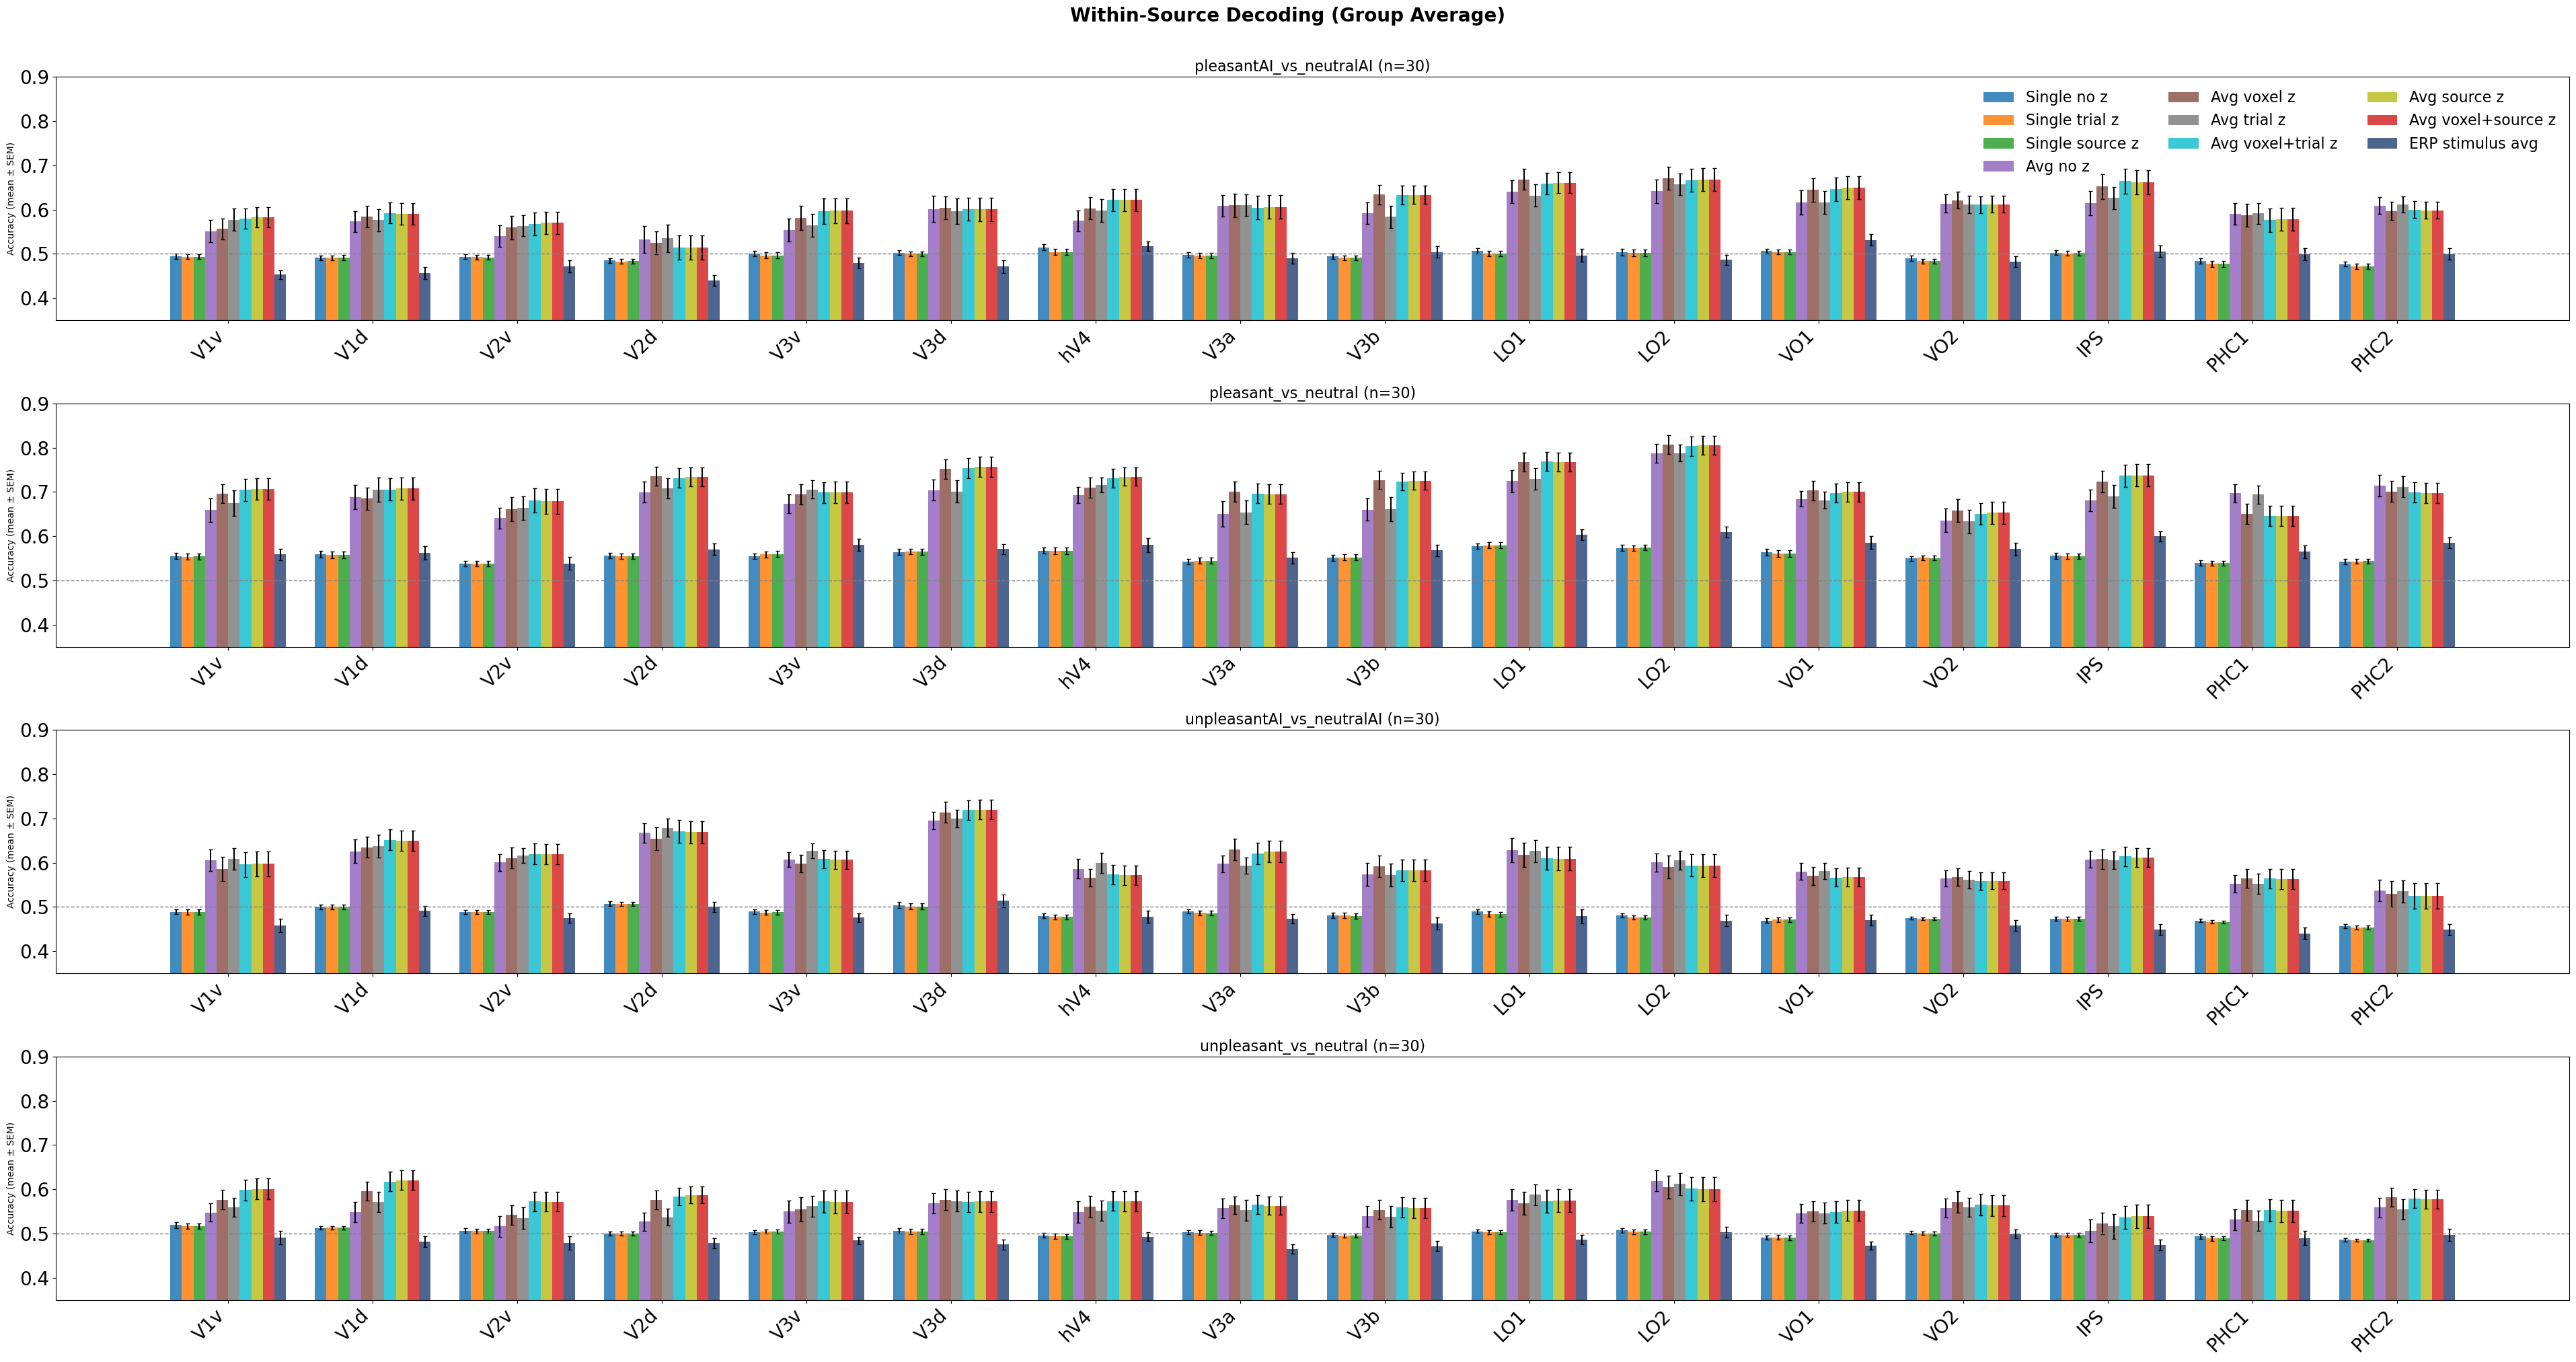

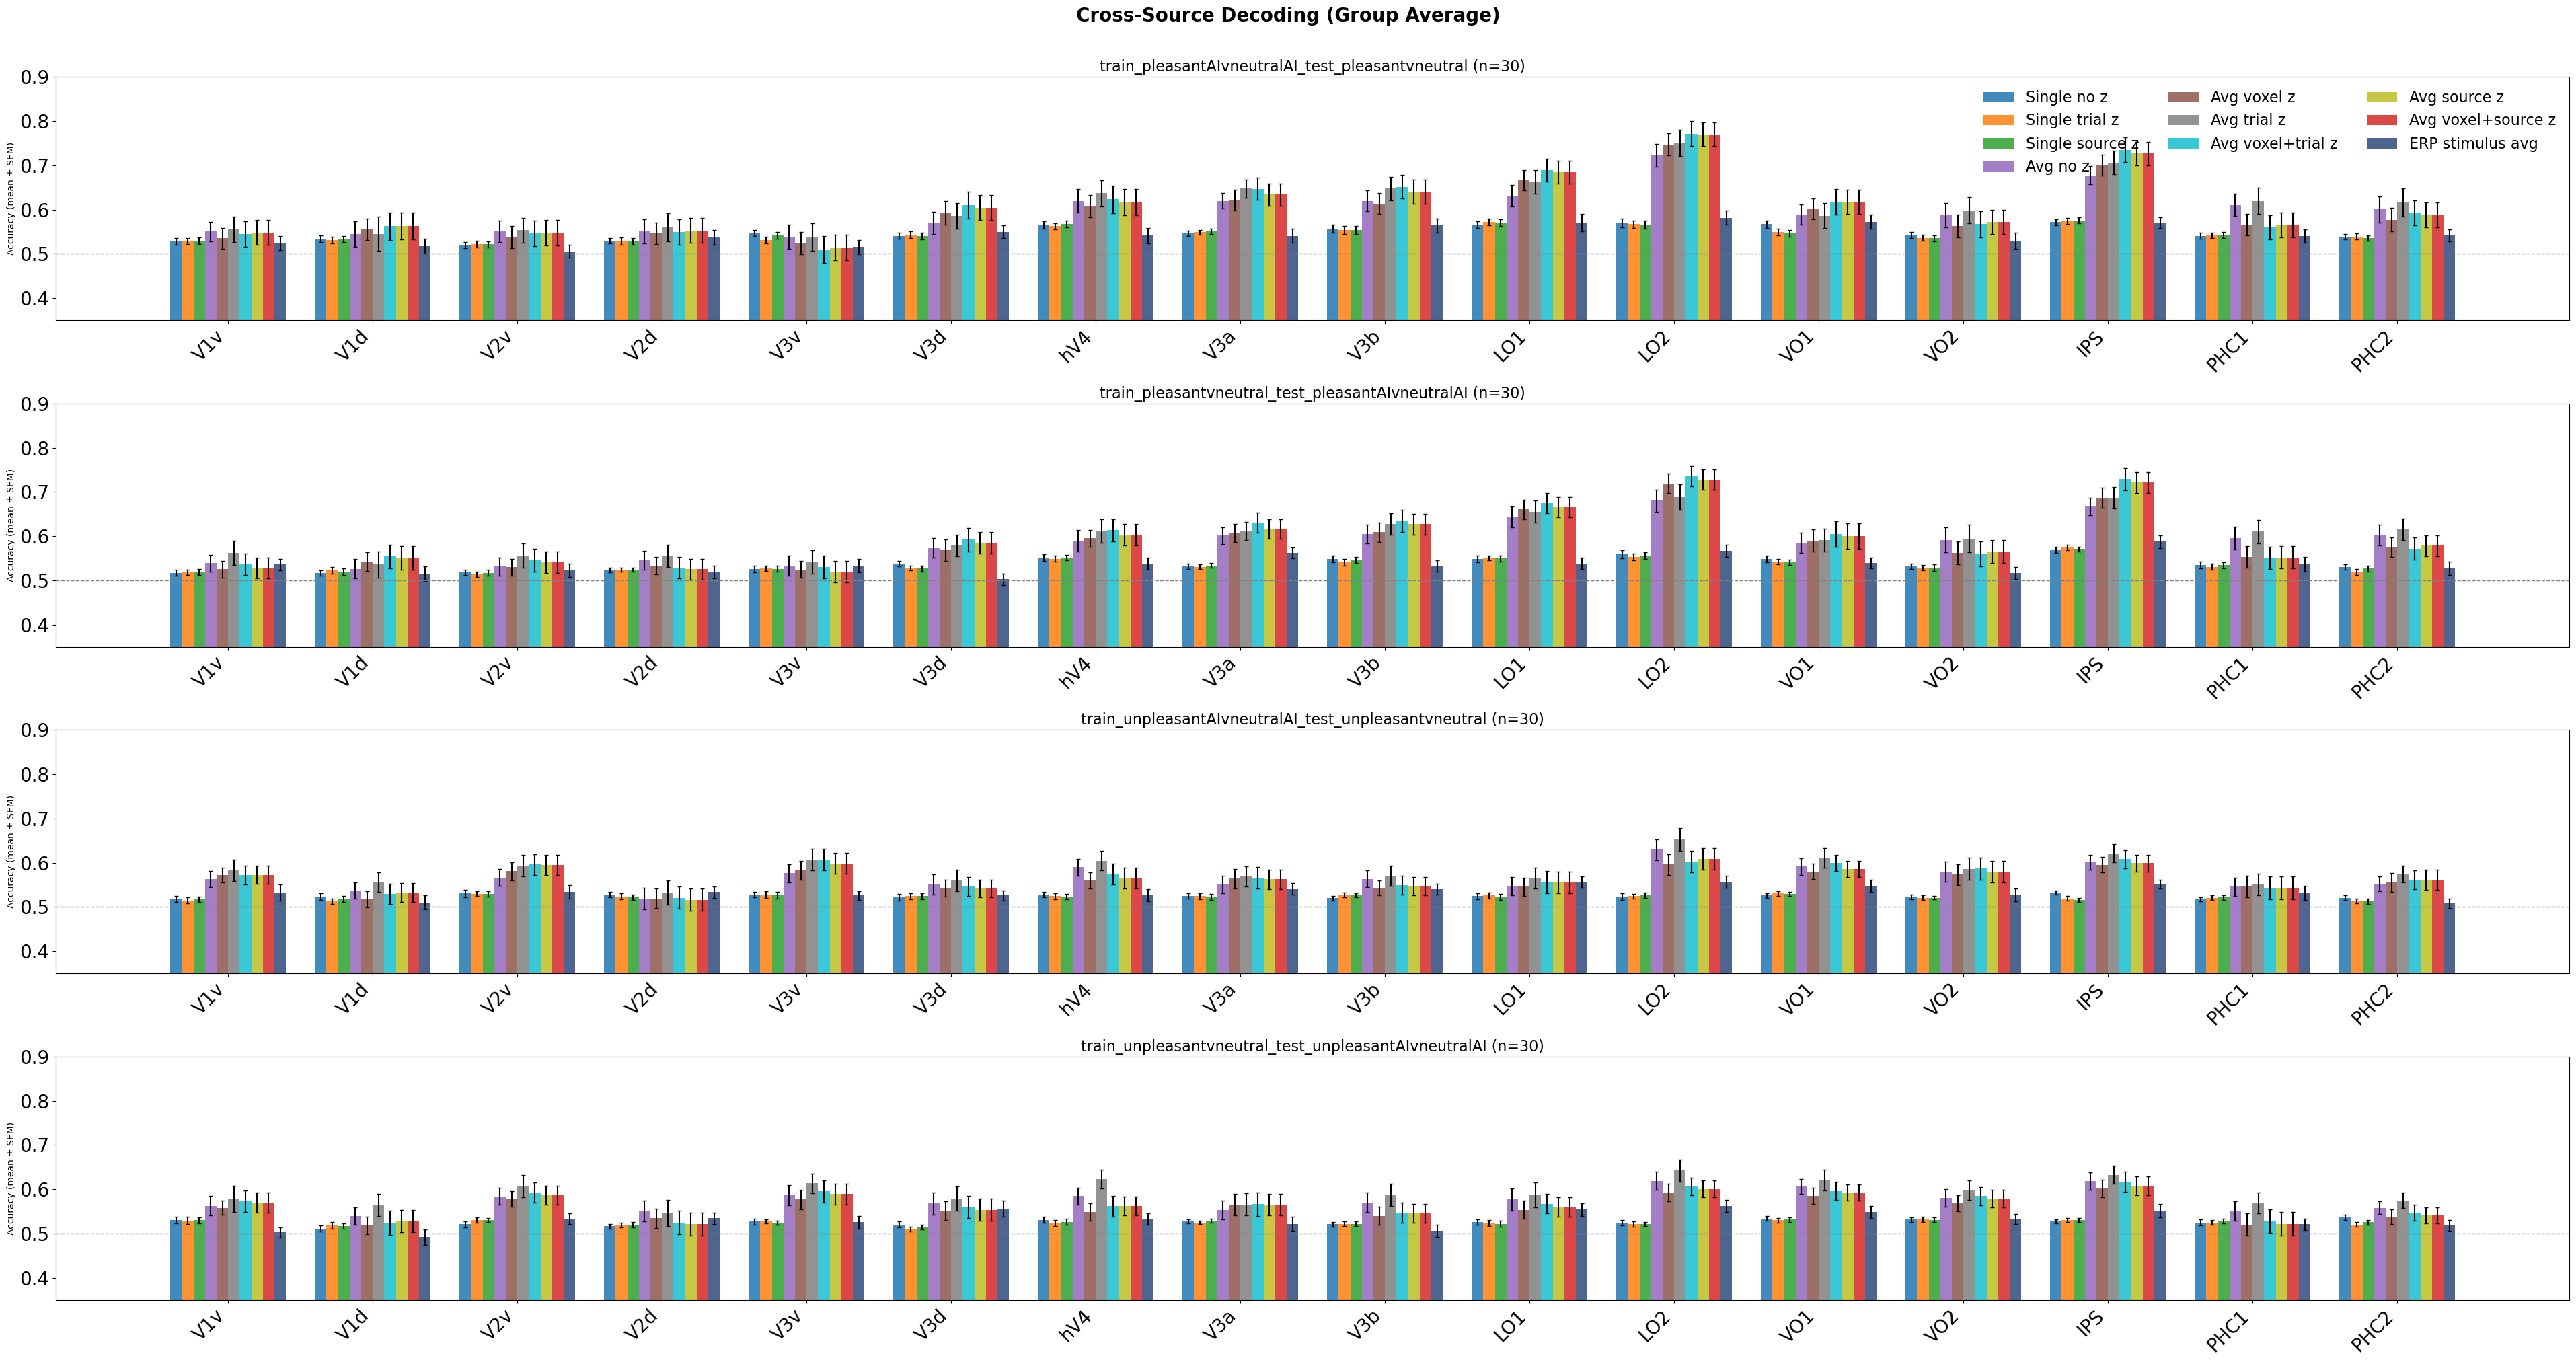

In [14]:
roi_names = list(roi_masks.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#7f7f7f', '#17becf', '#bcbd22', '#d62728', '#2f4b7c']
method_labels = [
    'Single no z',
    'Single trial z',
    'Single source z',
    'Avg no z',
    'Avg voxel z',
    'Avg trial z',
    'Avg voxel+trial z',
    'Avg source z',
    'Avg voxel+source z',
    'ERP stimulus avg'
]


def collect_method_data(comp, result_single, result_avg, result_erp):
    """Collect n_subjects x n_rois arrays for each method."""
    methods = []
    for zk in SINGLE_Z_MODES:
        arr = np.array([[result_single[s][comp][zk].get(r, np.nan) for r in roi_names] for s in subs])
        methods.append(arr)
    for zk in AVG_Z_MODES:
        arr = np.array([[result_avg[s][comp][zk].get(r, np.nan) for r in roi_names] for s in subs])
        methods.append(arr)
    arr = np.array([[result_erp[s][comp].get(r, np.nan) for r in roi_names] for s in subs])
    methods.append(arr)
    return methods


# --- Within-Source Plot ---
fig, axes = plt.subplots(len(within_comparisons), 1,
                         figsize=(max(22, len(roi_names)*2.4), 5*len(within_comparisons)),
                         squeeze=False)

for row, (cond1, cond2) in enumerate(within_comparisons):
    comp = f"{cond1}_vs_{cond2}"
    ax = axes[row, 0]
    method_data = collect_method_data(comp, results_within_single, results_within_avg, results_within_erp)

    x = np.arange(len(roi_names))
    n_m = len(method_data)
    width = min(0.10, 0.8 / n_m)

    for mi, (md, color, lab) in enumerate(zip(method_data, colors, method_labels)):
        means = np.nanmean(md, axis=0)
        sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))
        offset = (mi - (n_m-1)/2) * width
        ax.bar(x + offset, means, width, yerr=sems, color=color,
               label=lab, capsize=2, alpha=0.85)

    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Accuracy (mean ± SEM)')
    ax.set_title(f'{comp} (n={len(subs)})', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_ylim([0.35, 0.9])
    if row == 0:
        ax.legend(fontsize=16, loc='upper right', ncol=3, frameon=False)

fig.suptitle('Within-Source Decoding (Group Average)', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# --- Cross-Source Plot ---
fig, axes = plt.subplots(len(cross_comparisons), 1,
                         figsize=(max(22, len(roi_names)*2.4), 5*len(cross_comparisons)),
                         squeeze=False)

for row, (tc1, tc2, te1, te2) in enumerate(cross_comparisons):
    comp = f"train_{tc1}v{tc2}_test_{te1}v{te2}"
    ax = axes[row, 0]
    method_data = collect_method_data(comp, results_cross_single, results_cross_avg, results_cross_erp)

    x = np.arange(len(roi_names))
    n_m = len(method_data)
    width = min(0.10, 0.8 / n_m)

    for mi, (md, color, lab) in enumerate(zip(method_data, colors, method_labels)):
        means = np.nanmean(md, axis=0)
        sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))
        offset = (mi - (n_m-1)/2) * width
        ax.bar(x + offset, means, width, yerr=sems, color=color,
               label=lab, capsize=2, alpha=0.85)

    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Accuracy (mean ± SEM)')
    ax.set_title(f'{comp} (n={len(subs)})', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_ylim([0.35, 0.9])
    if row == 0:
        ax.legend(fontsize=16, loc='upper right', ncol=3, frameon=False)

fig.suptitle('Cross-Source Decoding (Group Average)', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


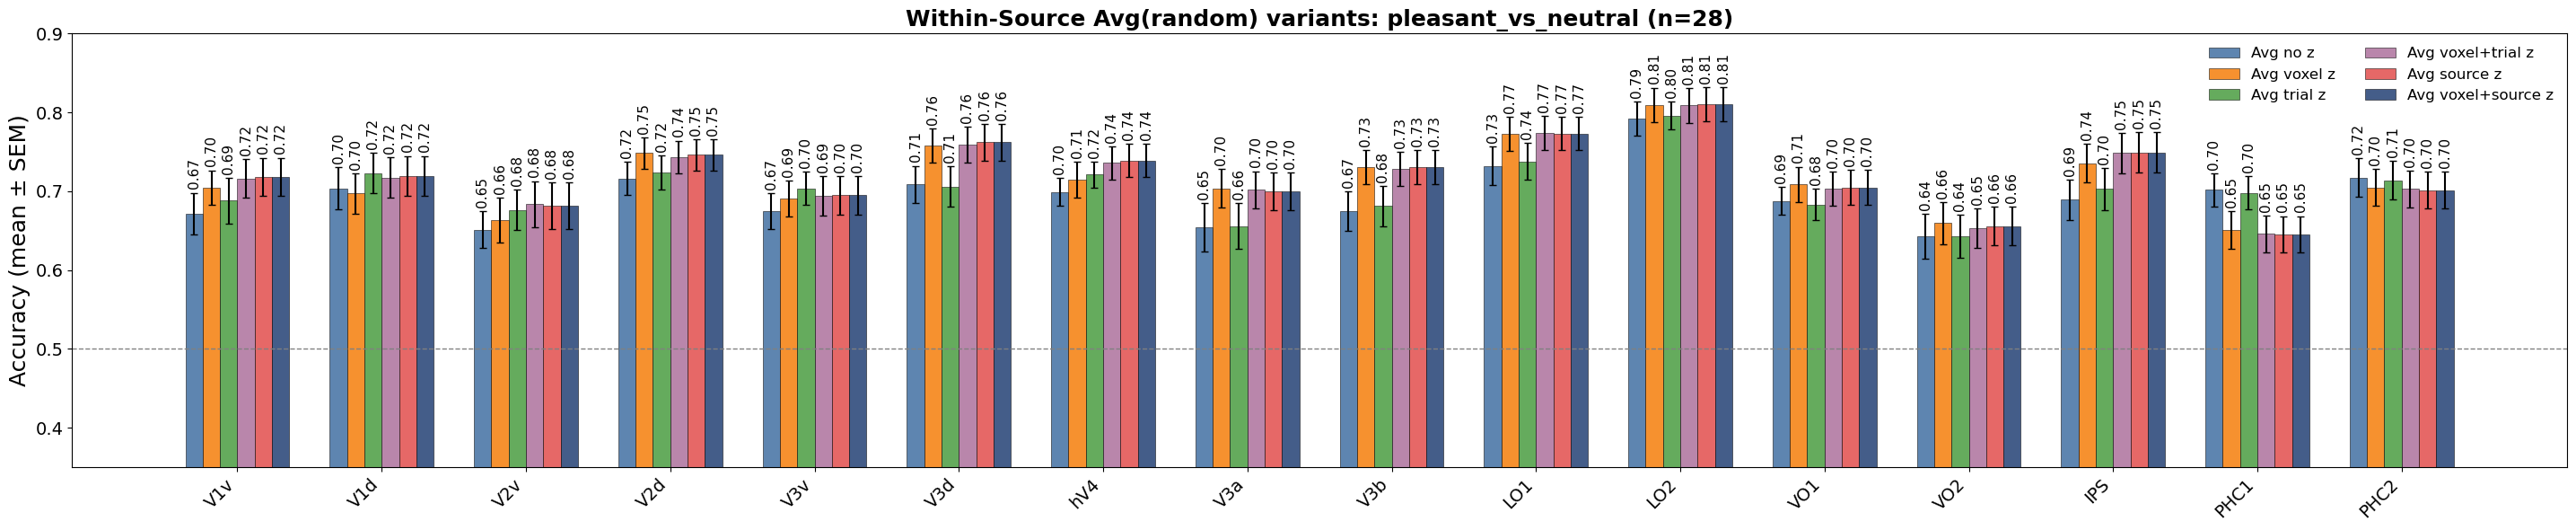

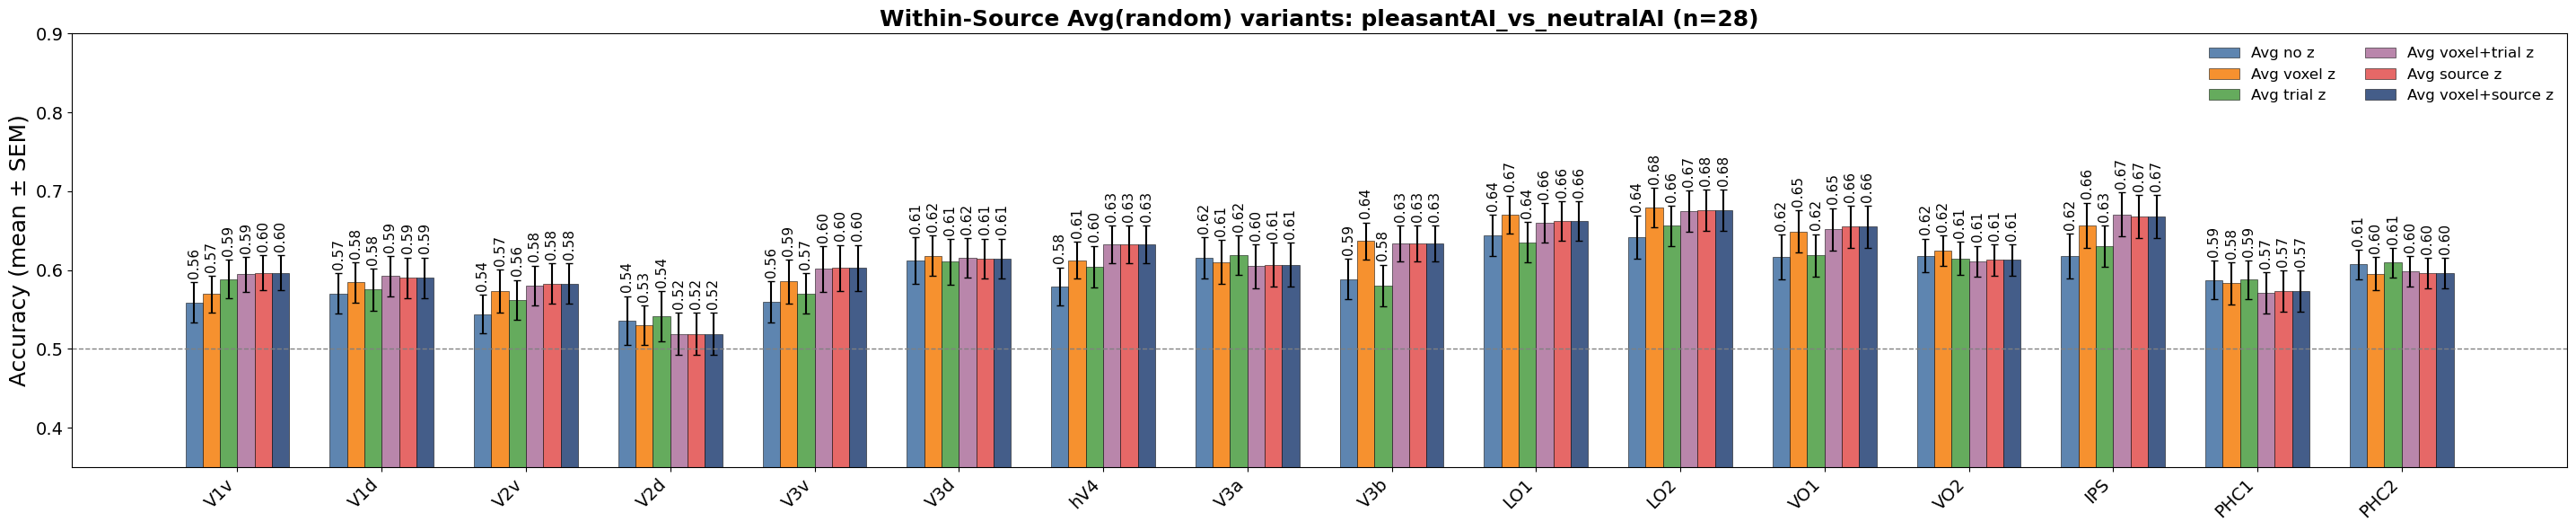

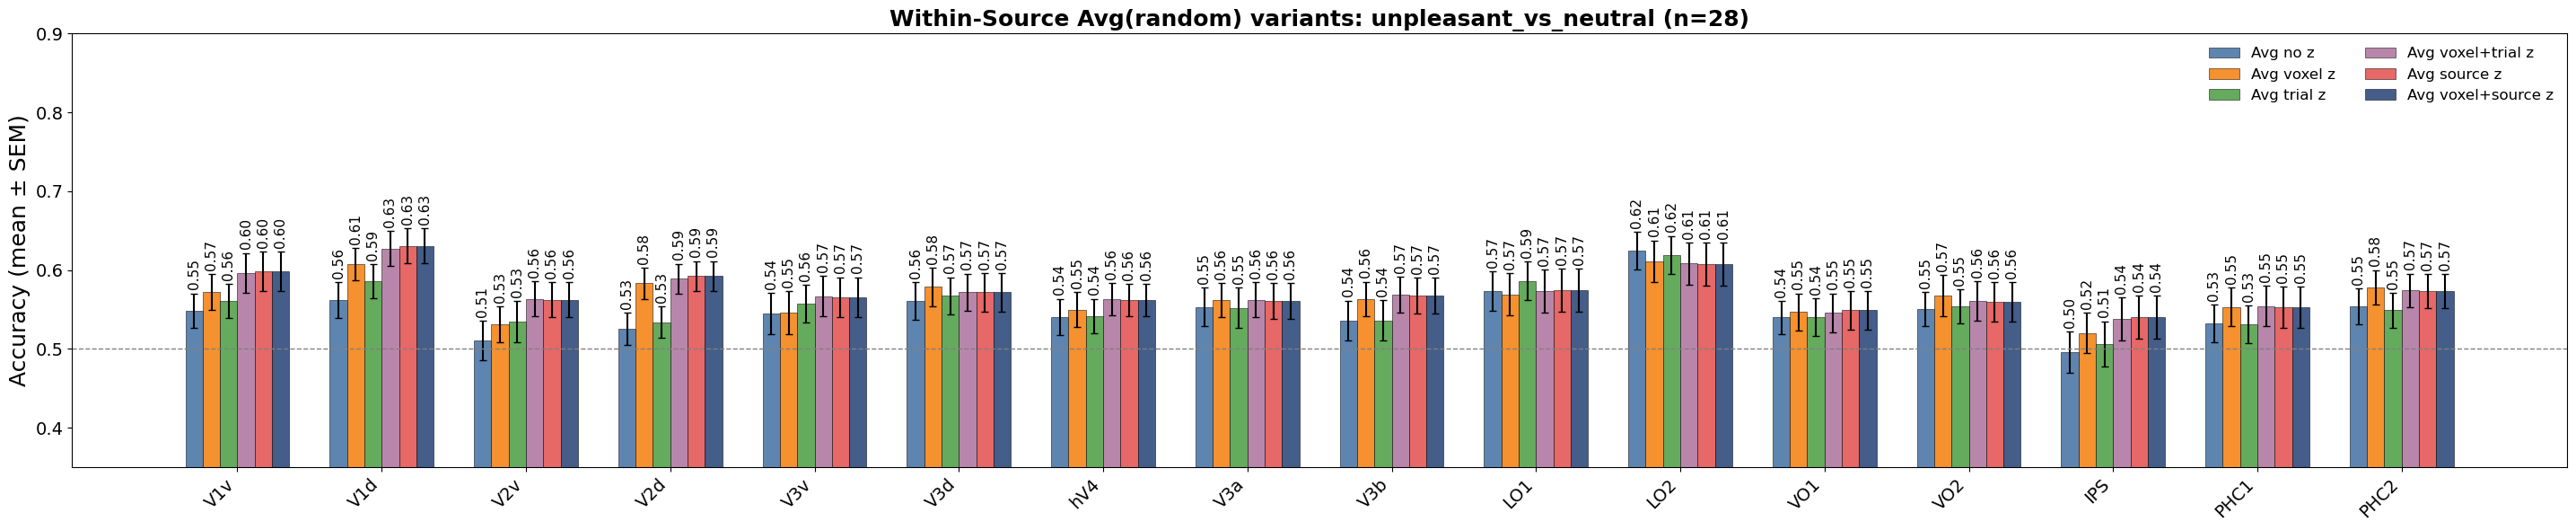

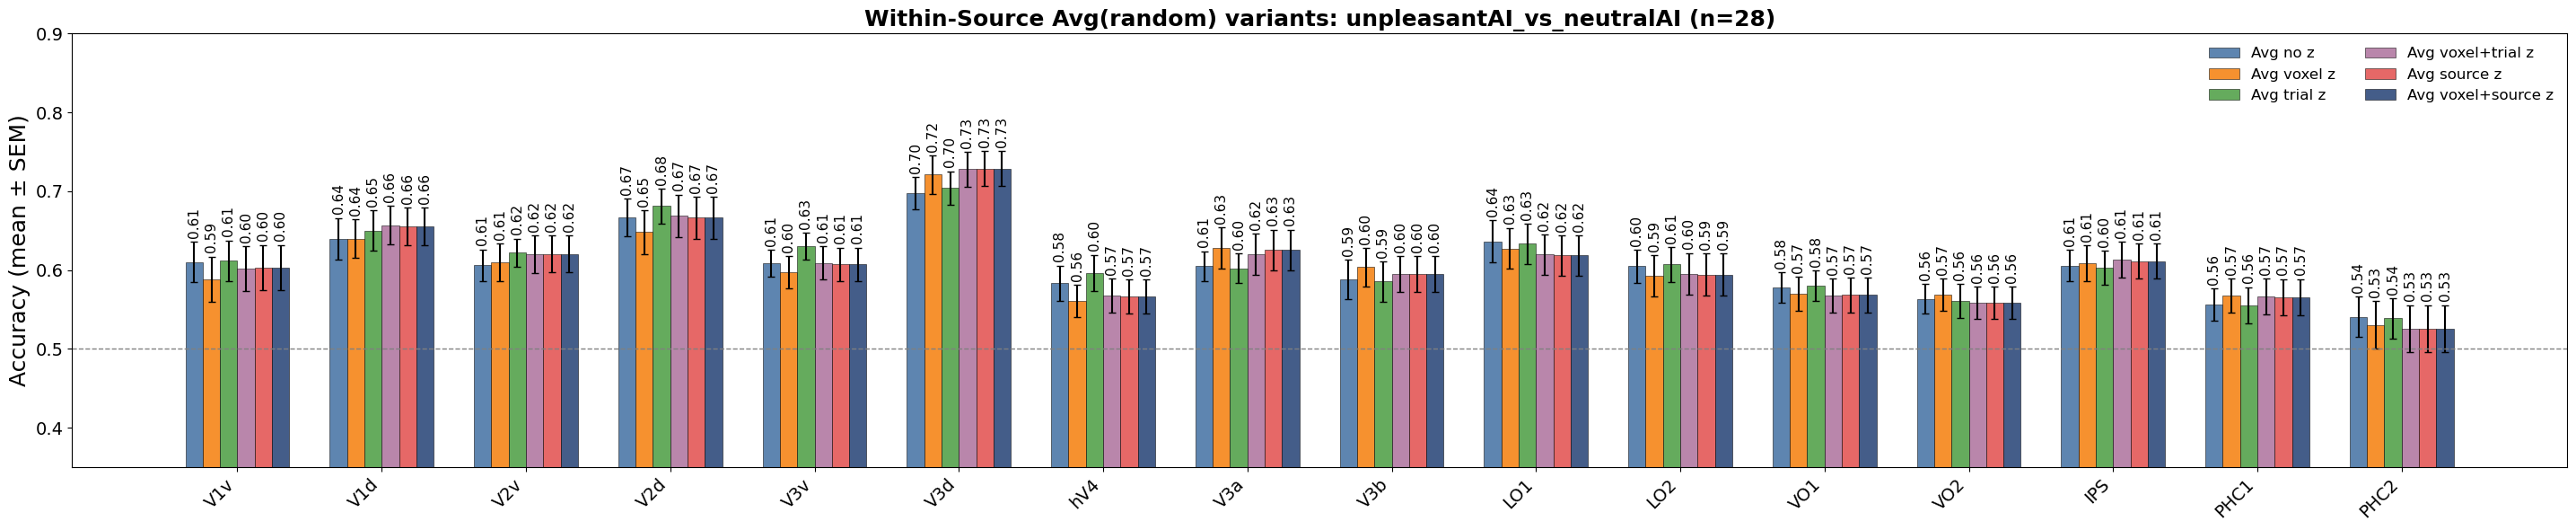

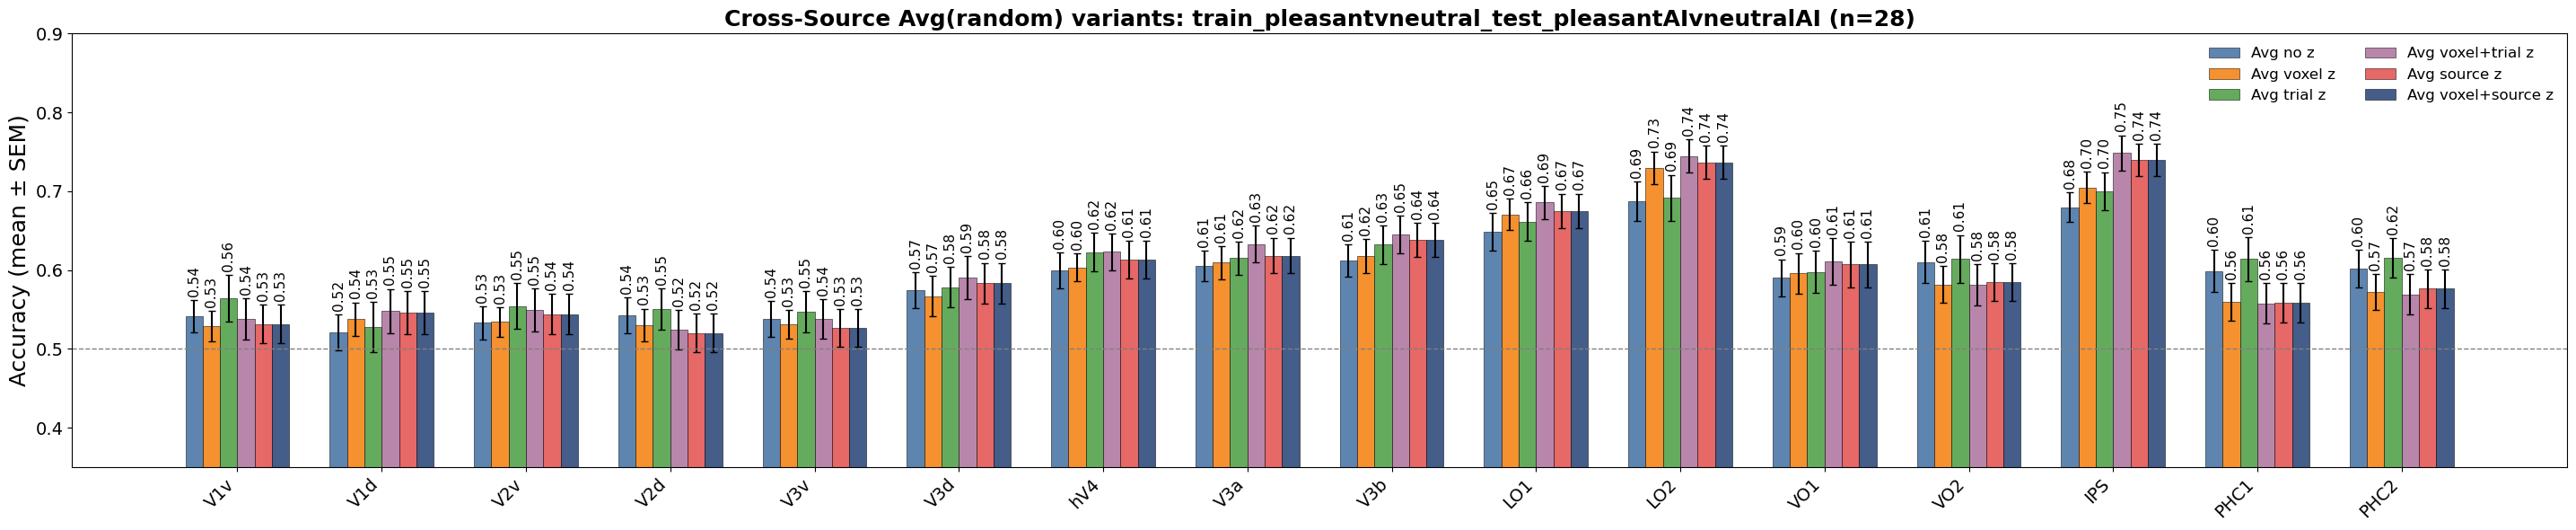

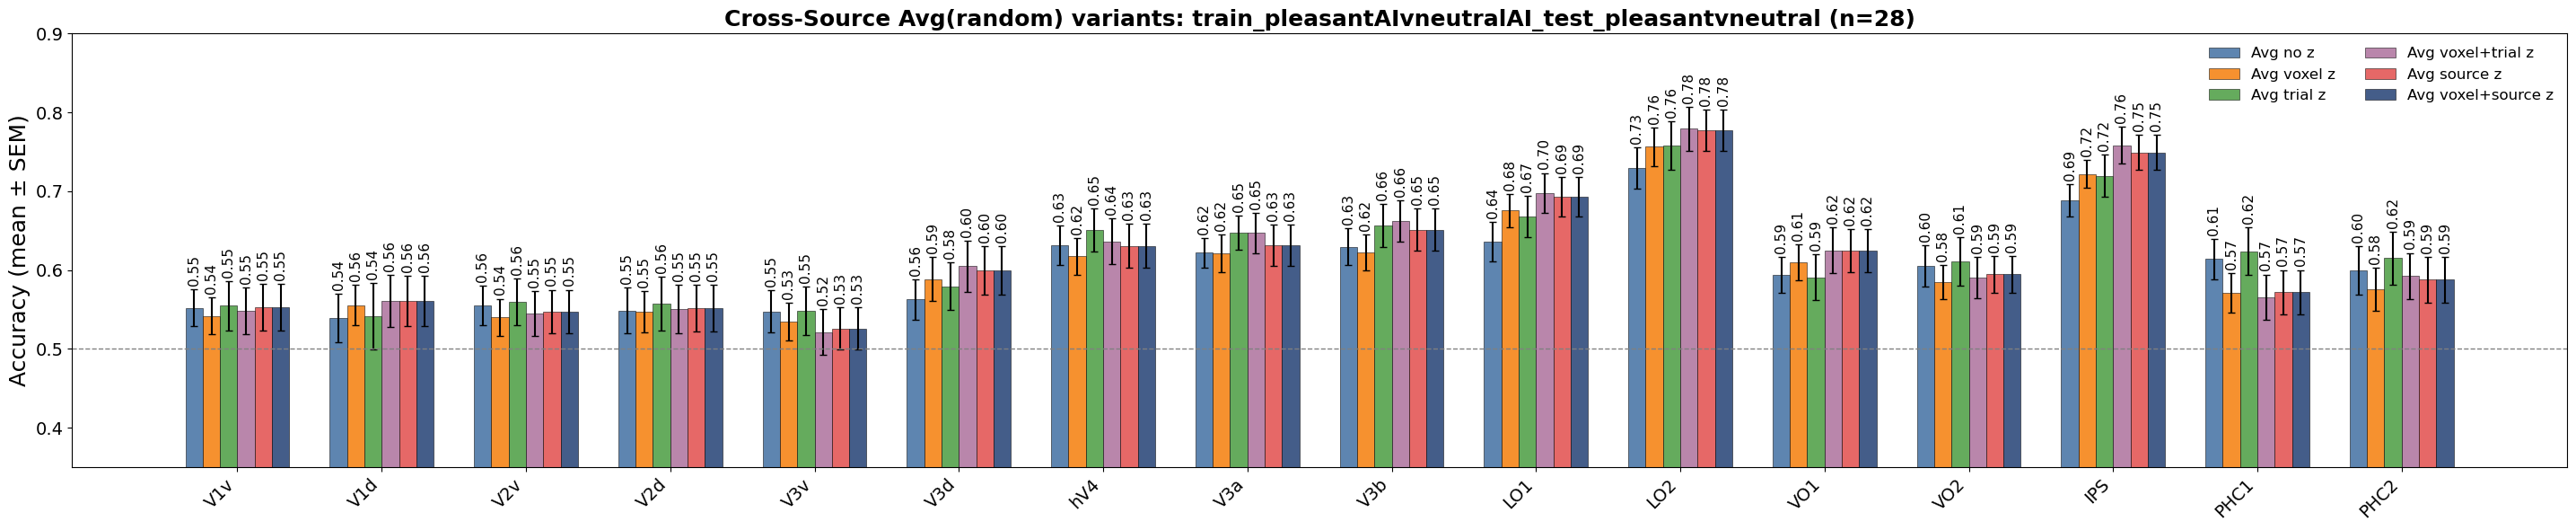

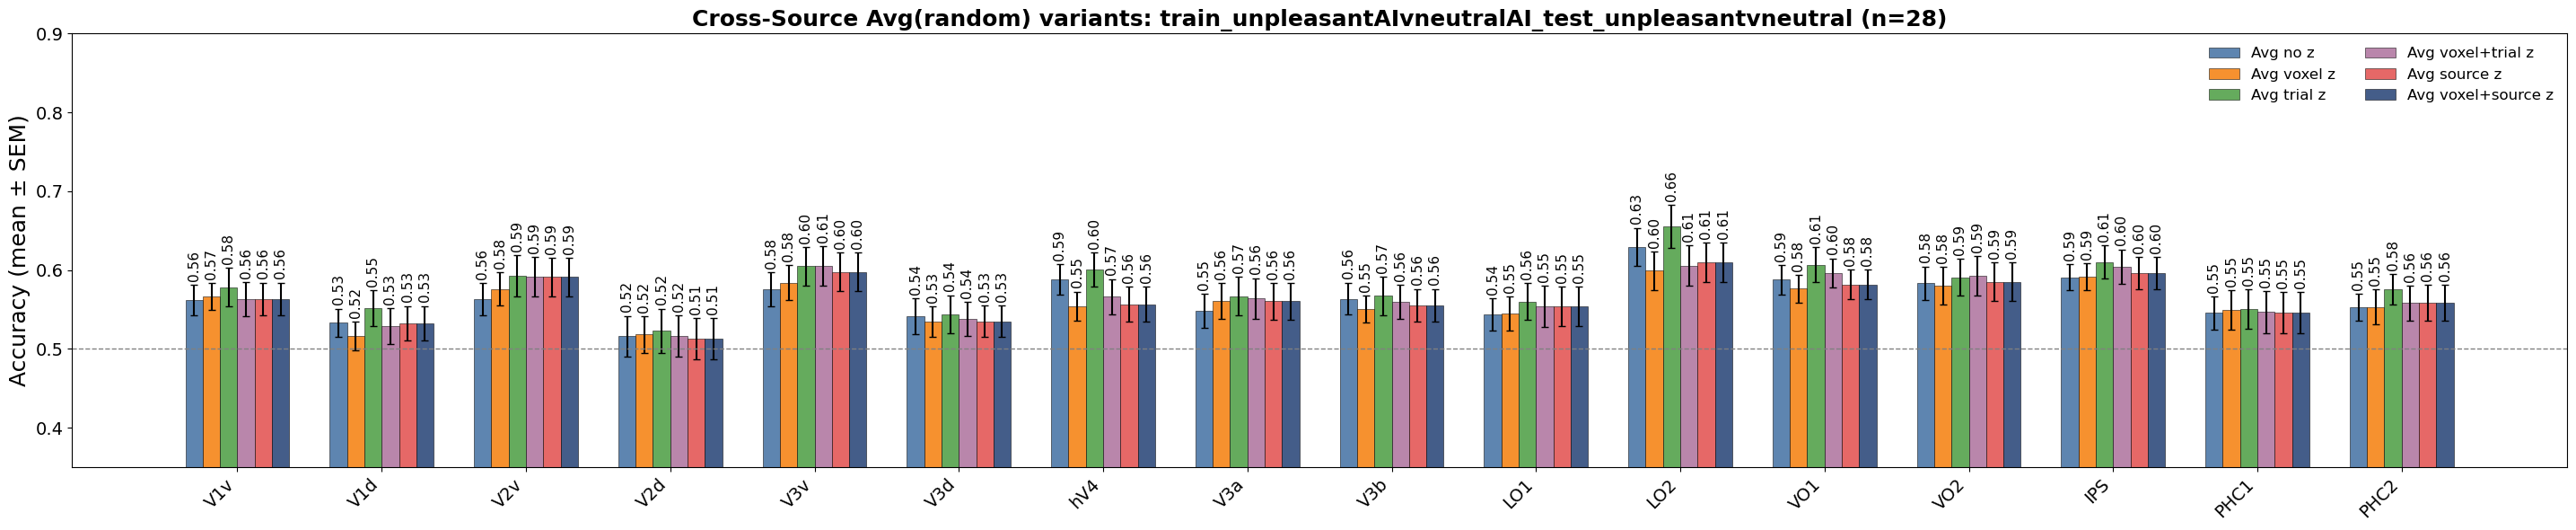

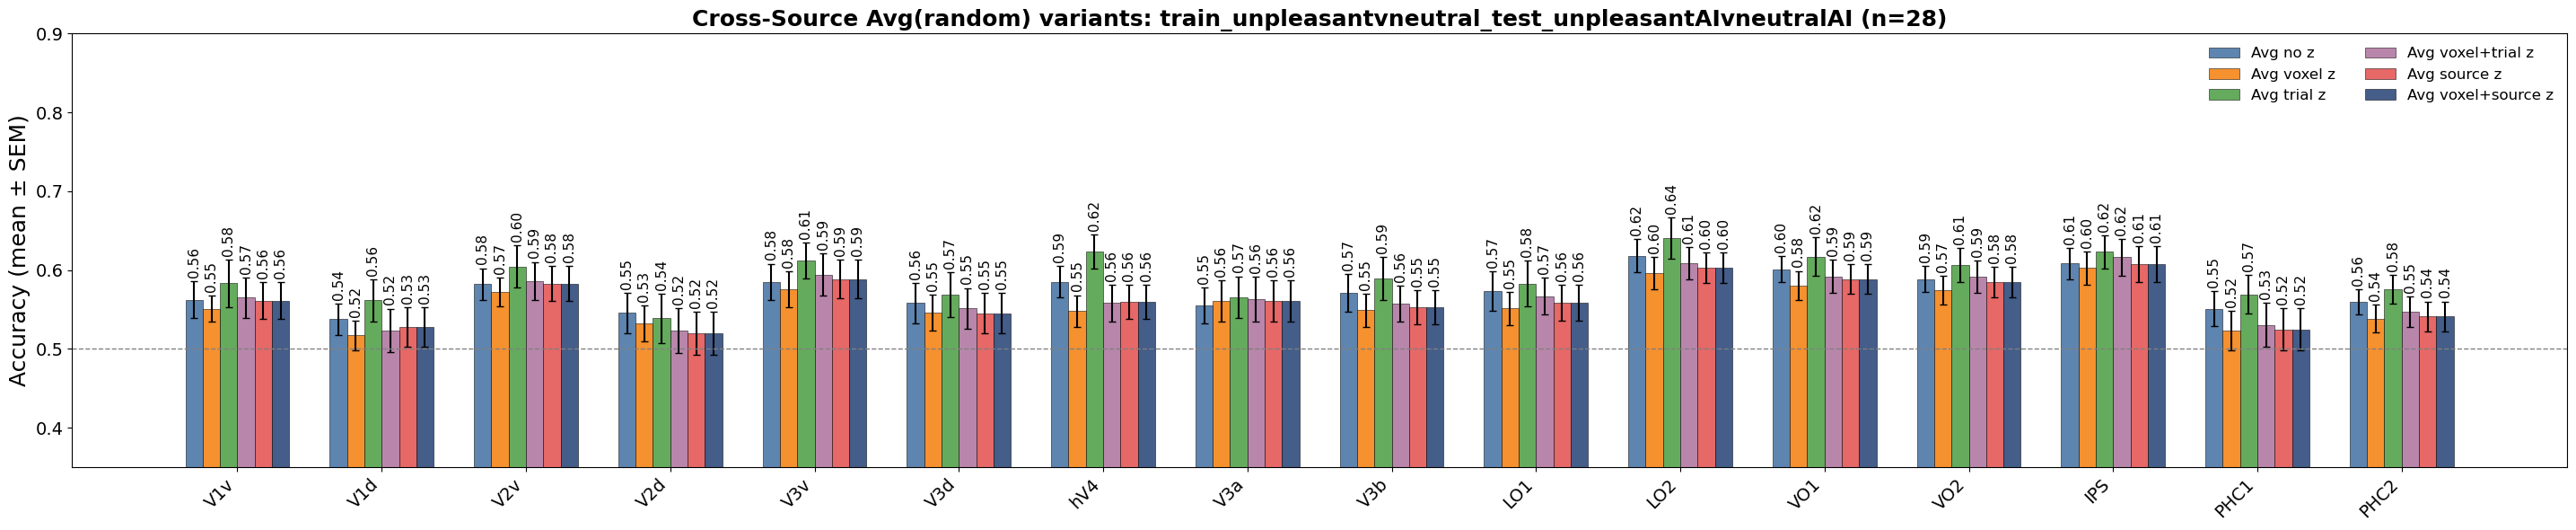

In [9]:
# ============================
# Avg(random) variants only
# Subjects: remove Sub3, Sub8
# ============================
subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]
roi_names = list(roi_masks.keys())

avg_variant_colors = {
    'no_zscore': '#4c78a8',
    'voxel_zscore': '#f58518',
    'trial_zscore': '#54a24b',
    'voxel_trial_zscore': '#b279a2',
    'source_zscore': '#e45756',
    'voxel_source_zscore': '#2f4b7c',
}

avg_variant_labels = {
    'no_zscore': 'Avg no z',
    'voxel_zscore': 'Avg voxel z',
    'trial_zscore': 'Avg trial z',
    'voxel_trial_zscore': 'Avg voxel+trial z',
    'source_zscore': 'Avg source z',
    'voxel_source_zscore': 'Avg voxel+source z',
}


def collect_avg_variant_data(comp, result_avg, z_mode):
    """Collect Avg(random) variant: n_subjects x n_rois."""
    return np.array([
        [result_avg[s][comp][z_mode].get(r, np.nan) for r in roi_names]
        for s in subs_plot
    ])


def plot_avg_variants_for_comp(result_avg, comp, title):
    fig, ax = plt.subplots(1, 1, figsize=(max(18, len(roi_names) * 1.8), 6))
    x = np.arange(len(roi_names))
    width = min(0.12, 0.8 / len(AVG_Z_MODES))
    n_m = len(AVG_Z_MODES)

    for mi, z_mode in enumerate(AVG_Z_MODES):
        md = collect_avg_variant_data(comp, result_avg, z_mode)
        means = np.nanmean(md, axis=0)
        sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))
        offset = (mi - (n_m - 1) / 2) * width

        bars = ax.bar(
            x + offset, means, width, yerr=sems,
            color=avg_variant_colors[z_mode], label=avg_variant_labels[z_mode],
            capsize=3, alpha=0.9, edgecolor='black', linewidth=0.4
        )
        ax.bar_label(bars, fmt='%.2f', fontsize=11, rotation=90, padding=3)

    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Accuracy (mean ± SEM)', fontsize=18)
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=14)
    ax.set_ylim([0.35, 0.9])
    ax.legend(fontsize=12, frameon=False, loc='upper right', ncol=2)
    plt.tight_layout()
    plt.show()


for comp in ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI',
             'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']:
    plot_avg_variants_for_comp(
        results_within_avg,
        comp,
        f'Within-Source Avg(random) variants: {comp} (n={len(subs_plot)})'
    )

for comp in ['train_pleasantvneutral_test_pleasantAIvneutralAI',
             'train_pleasantAIvneutralAI_test_pleasantvneutral',
             'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
             'train_unpleasantvneutral_test_unpleasantAIvneutralAI']:
    plot_avg_variants_for_comp(
        results_cross_avg,
        comp,
        f'Cross-Source Avg(random) variants: {comp} (n={len(subs_plot)})'
    )


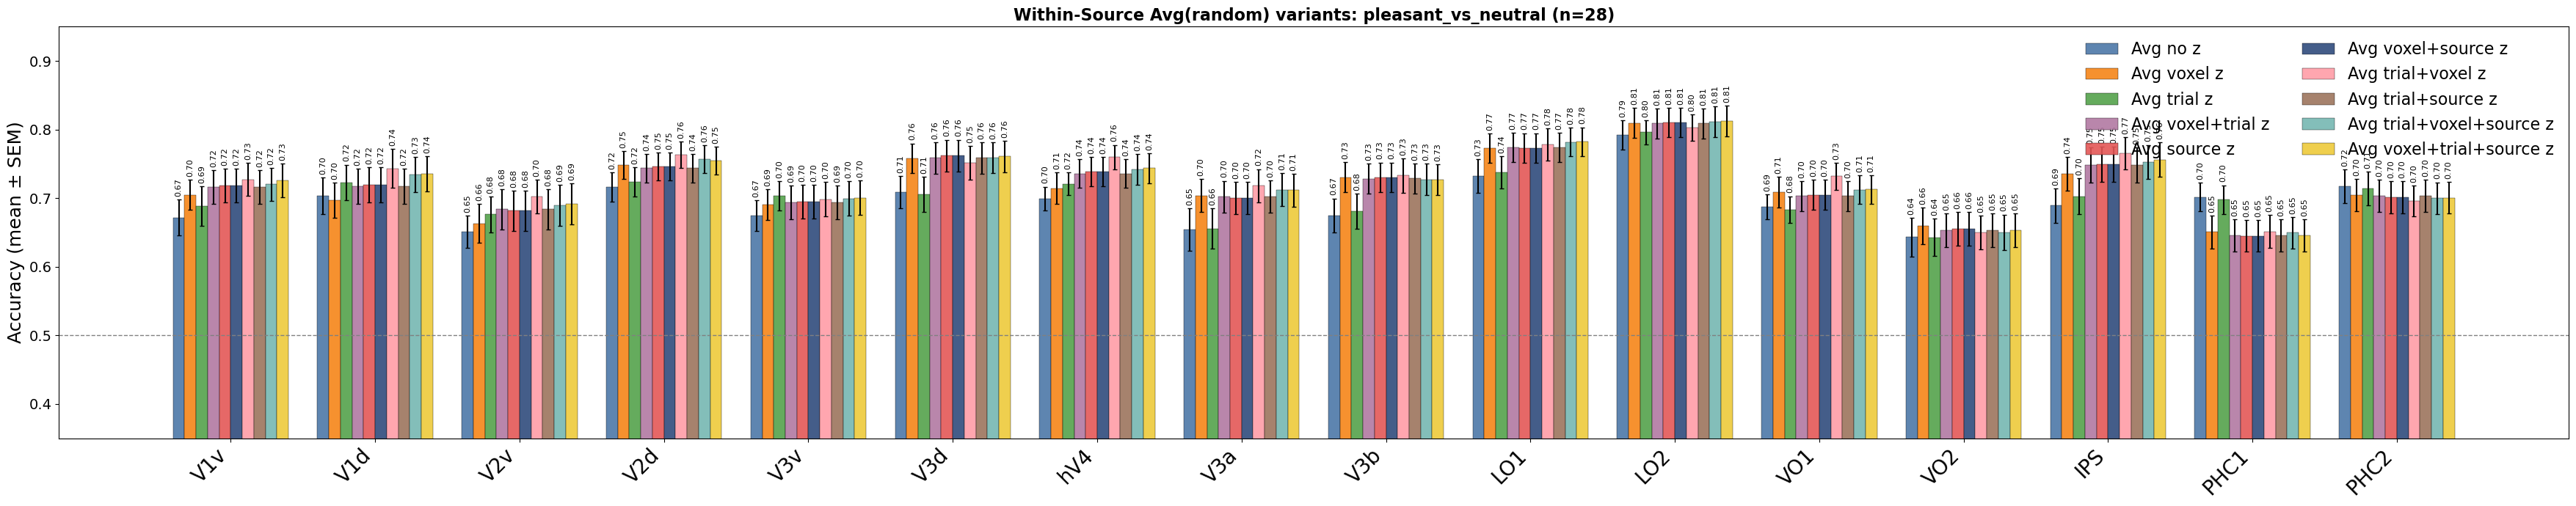

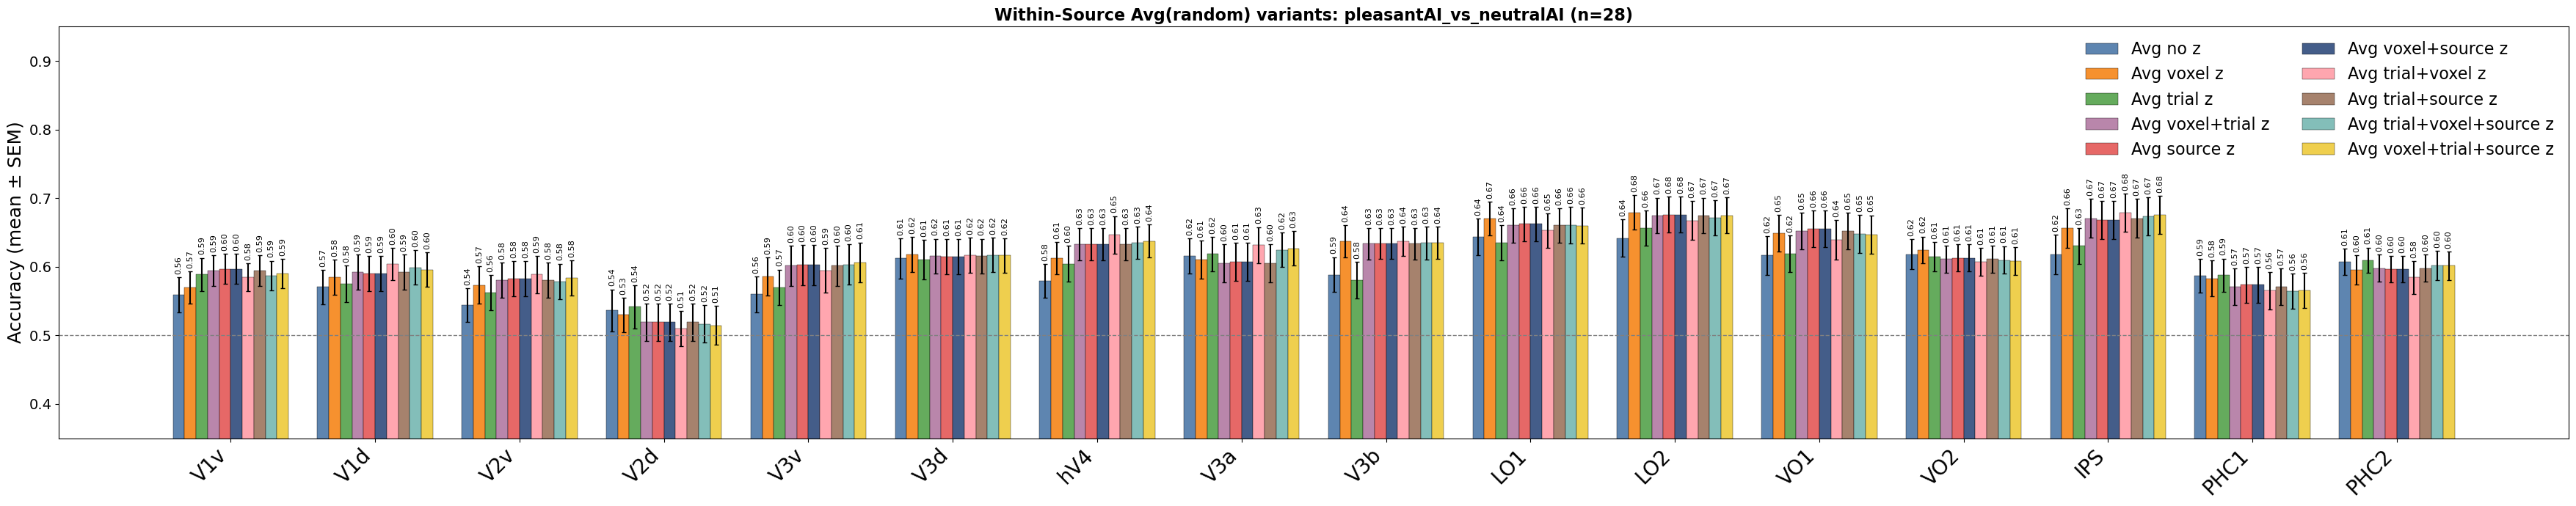

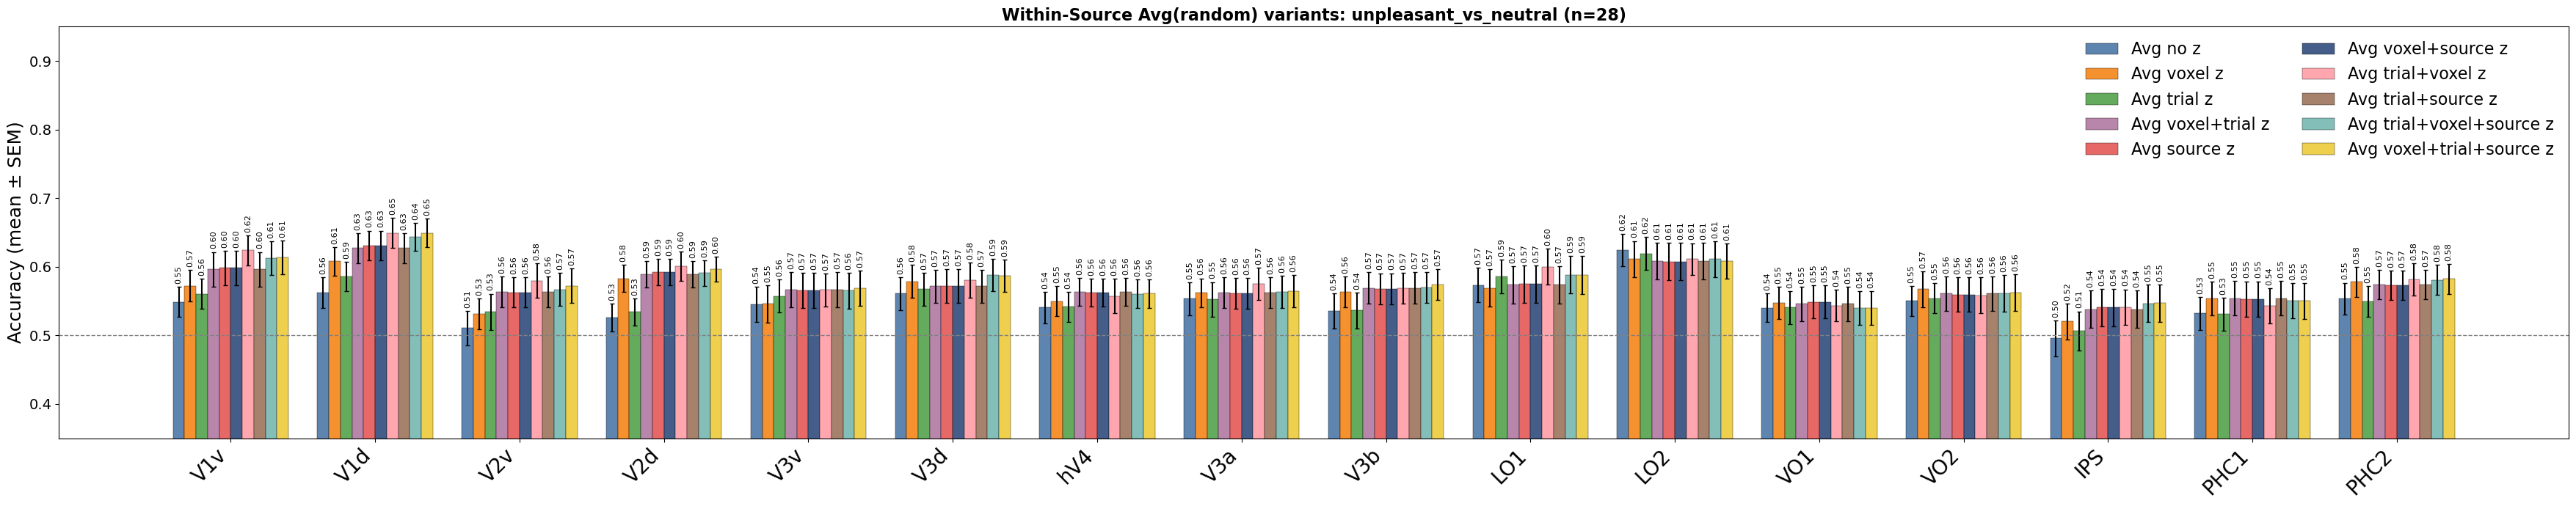

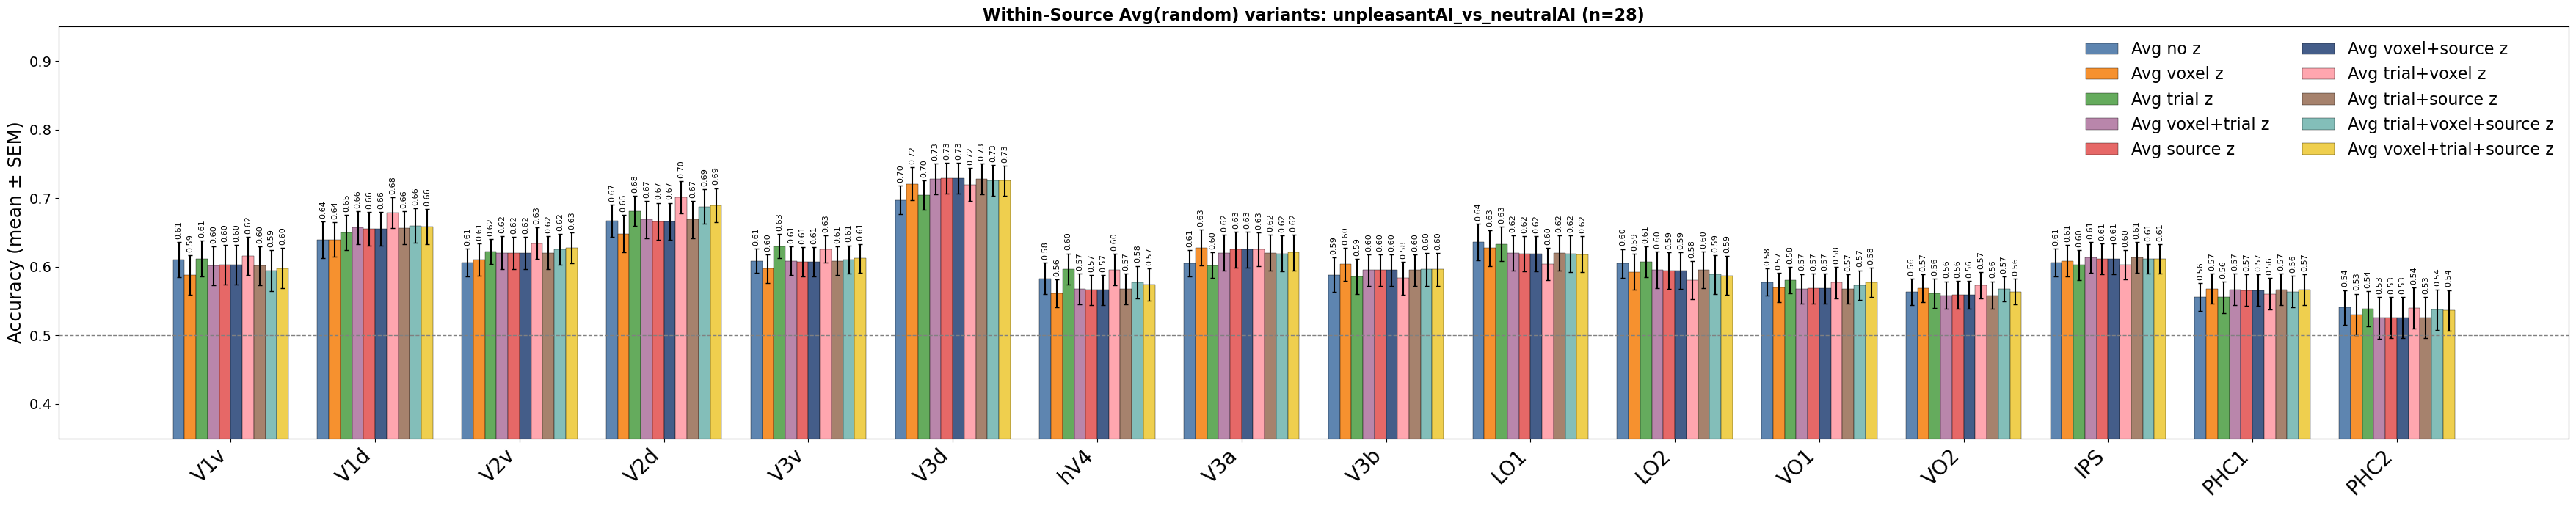

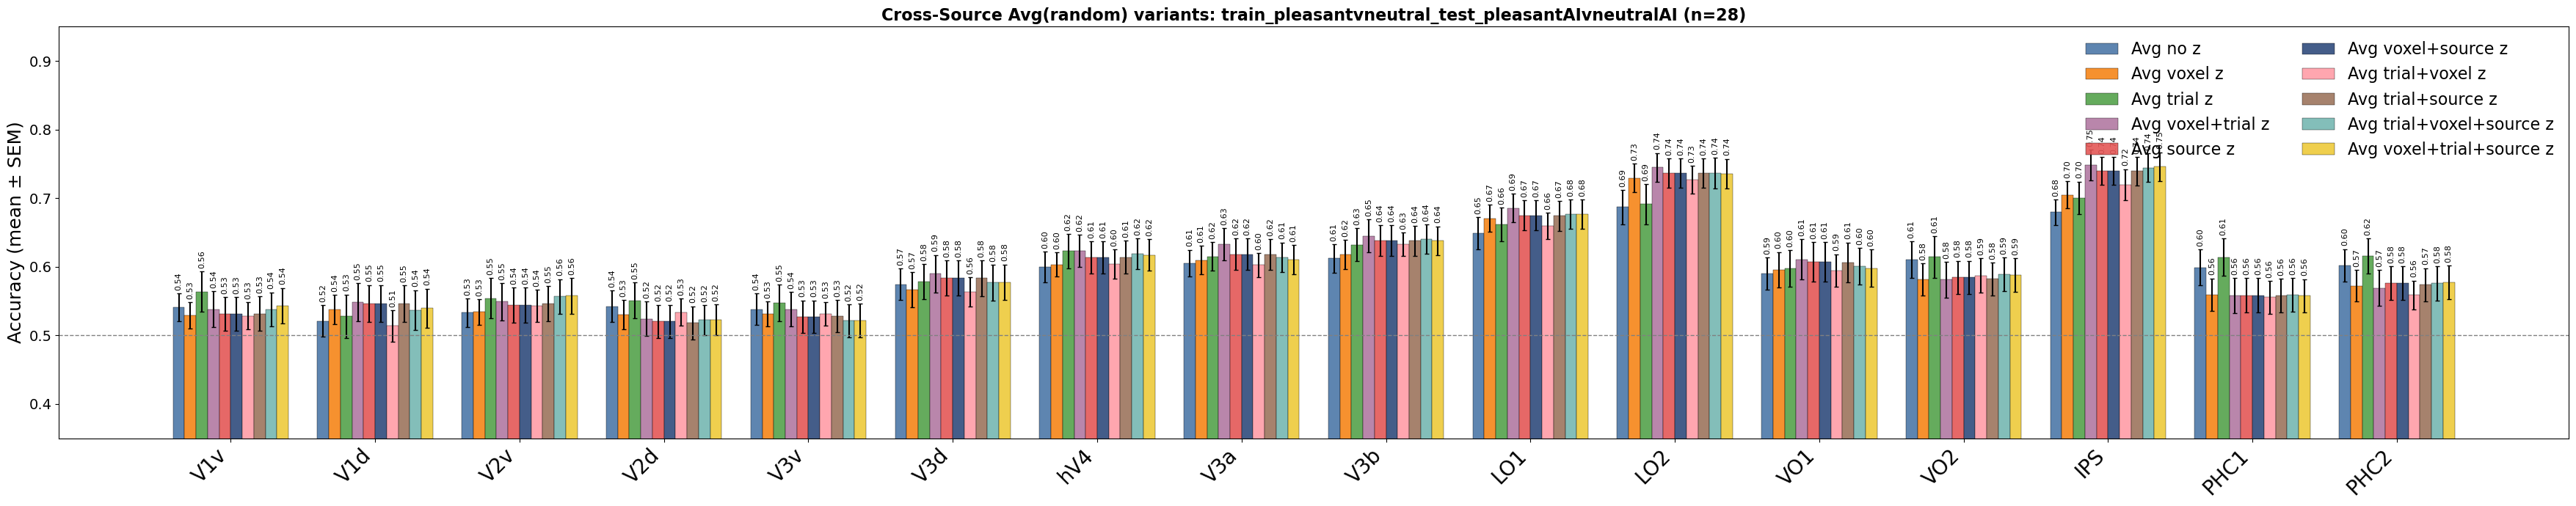

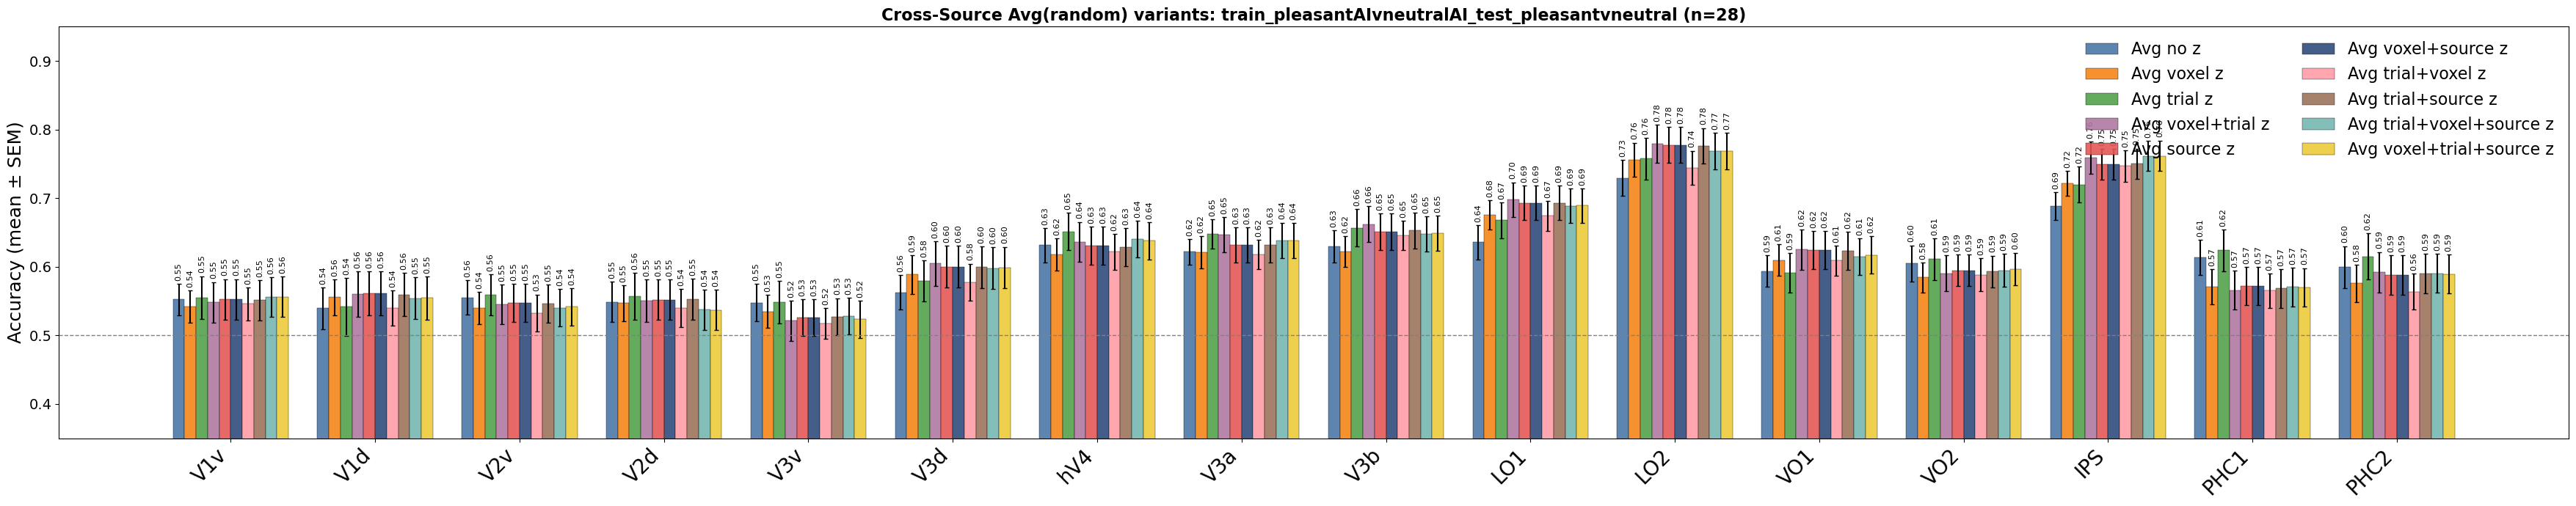

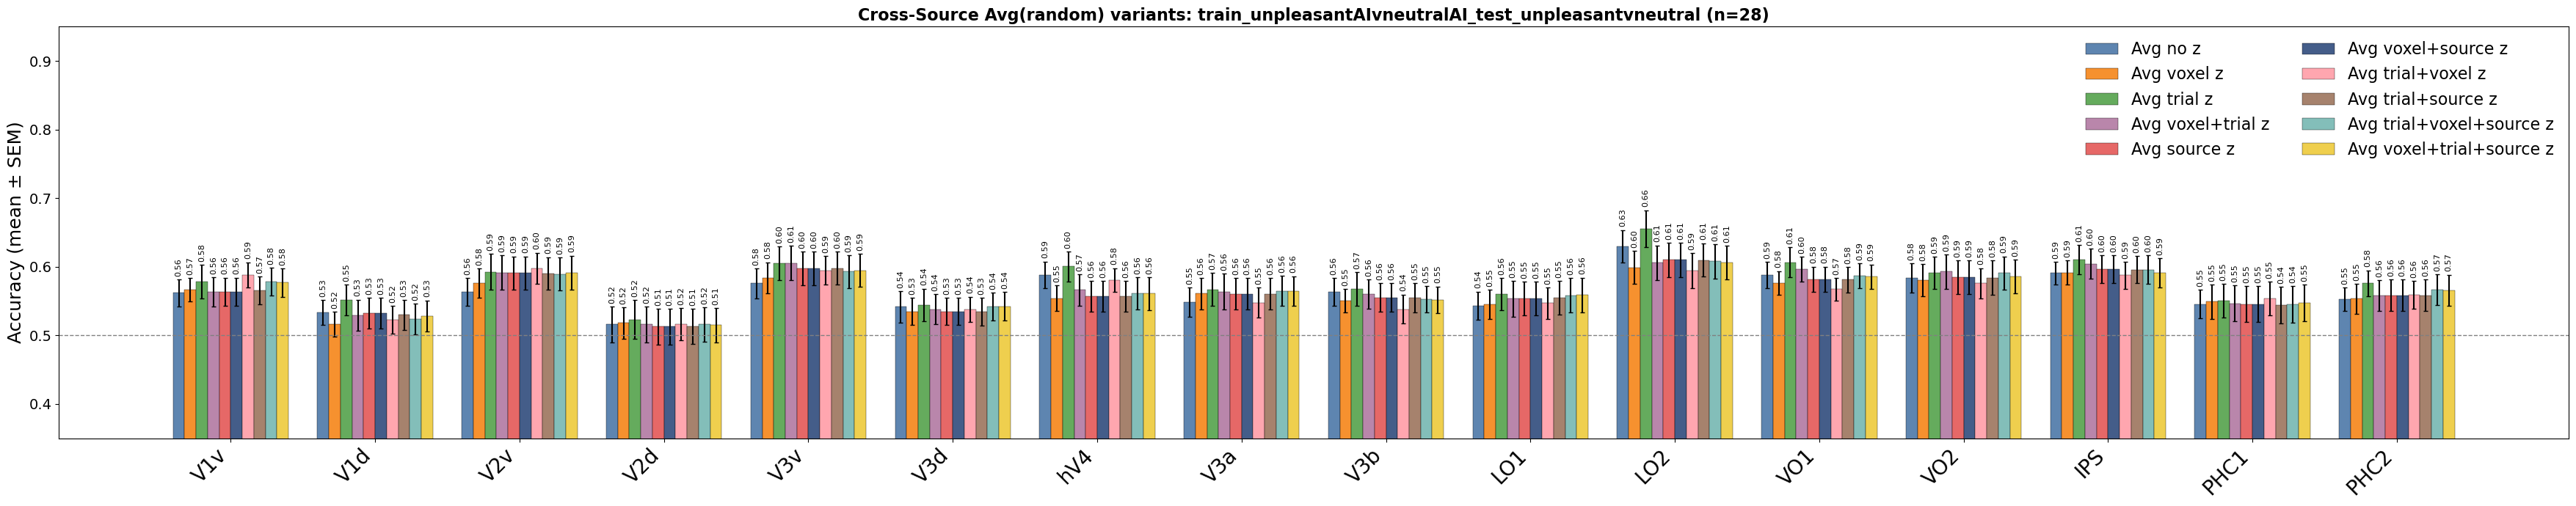

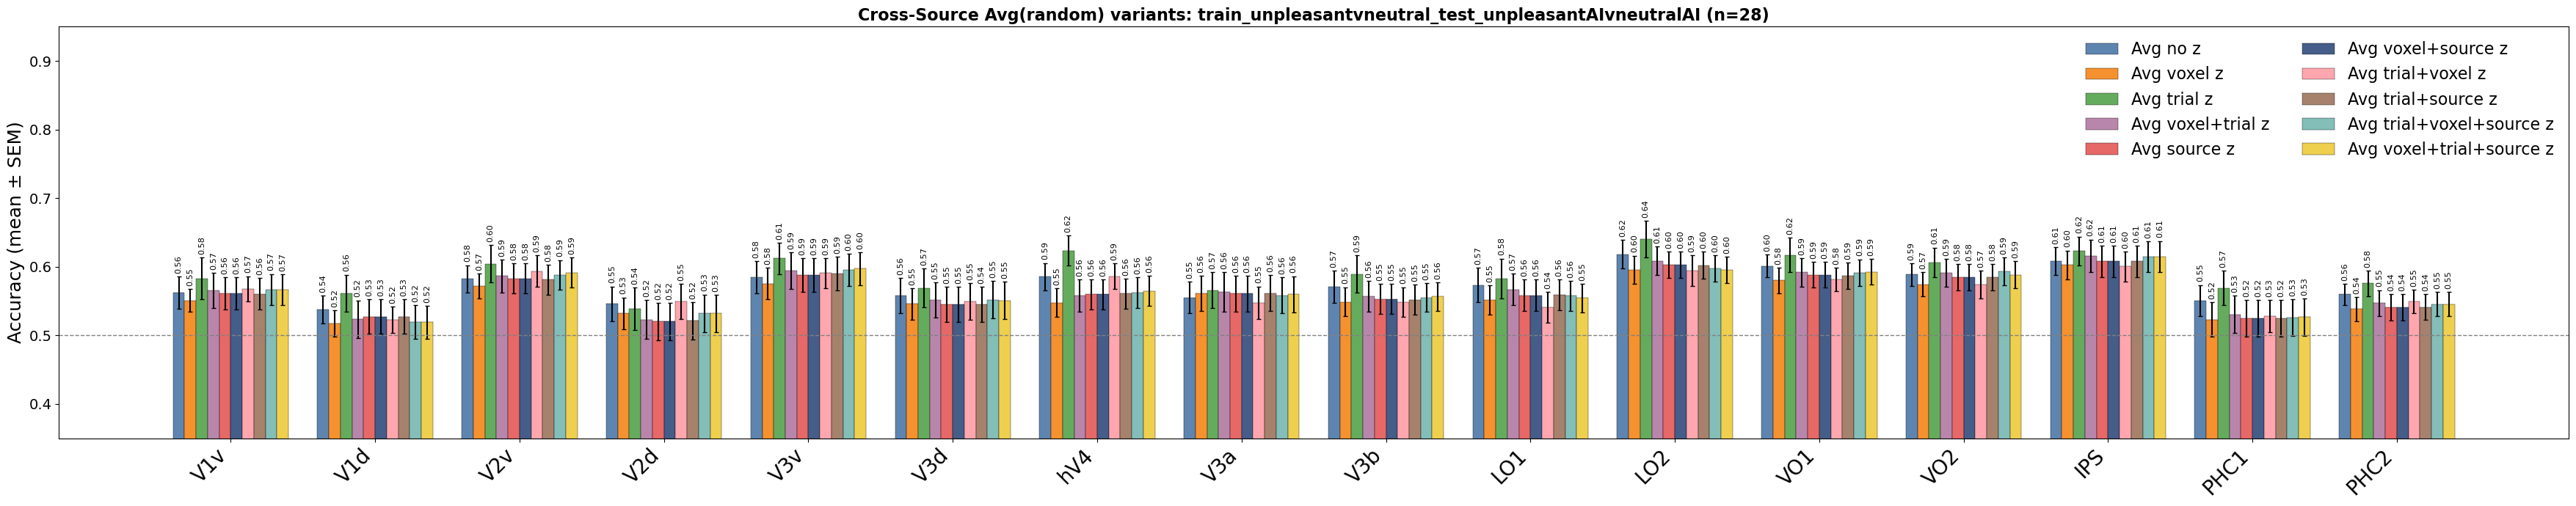

In [20]:
# ============================
# Avg(random) variants — all 10 modes
# Subjects: remove Sub3, Sub8
# ============================
subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]
roi_names = list(roi_masks.keys())

avg_variant_colors = {
    'no_zscore': '#4c78a8',
    'voxel_zscore': '#f58518',
    'trial_zscore': '#54a24b',
    'voxel_trial_zscore': '#b279a2',
    'source_zscore': '#e45756',
    'voxel_source_zscore': '#2f4b7c',
    'trial_voxel_zscore': '#ff9da7',
    'trial_source_zscore': '#9d755d',
    'trial_voxel_source_zscore': '#76b7b2',
    'voxel_trial_source_zscore': '#eeca3b',
}

avg_variant_labels = {
    'no_zscore': 'Avg no z',
    'voxel_zscore': 'Avg voxel z',
    'trial_zscore': 'Avg trial z',
    'voxel_trial_zscore': 'Avg voxel+trial z',
    'source_zscore': 'Avg source z',
    'voxel_source_zscore': 'Avg voxel+source z',
    'trial_voxel_zscore': 'Avg trial+voxel z',
    'trial_source_zscore': 'Avg trial+source z',
    'trial_voxel_source_zscore': 'Avg trial+voxel+source z',
    'voxel_trial_source_zscore': 'Avg voxel+trial+source z',
}


def collect_avg_variant_data(comp, result_avg, z_mode):
    """Collect Avg(random) variant: n_subjects x n_rois."""
    return np.array([
        [result_avg[s][comp][z_mode].get(r, np.nan) for r in roi_names]
        for s in subs_plot
    ])


def plot_avg_variants_for_comp(result_avg, comp, title):
    fig, ax = plt.subplots(1, 1, figsize=(max(22, len(roi_names) * 2.2), 7))
    x = np.arange(len(roi_names))
    n_m = len(AVG_Z_MODES)
    width = min(0.08, 0.85 / n_m)

    for mi, z_mode in enumerate(AVG_Z_MODES):
        md = collect_avg_variant_data(comp, result_avg, z_mode)
        means = np.nanmean(md, axis=0)
        sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))
        offset = (mi - (n_m - 1) / 2) * width

        bars = ax.bar(
            x + offset, means, width, yerr=sems,
            color=avg_variant_colors[z_mode], label=avg_variant_labels[z_mode],
            capsize=2, alpha=0.9, edgecolor='black', linewidth=0.3
        )
        ax.bar_label(bars, fmt='%.2f', fontsize=8, rotation=90, padding=3)

    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Accuracy (mean ± SEM)', fontsize=18)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=20)
    ax.set_ylim([0.35, 0.95])
    ax.legend(fontsize=16, frameon=False, loc='upper right', ncol=2)
    plt.tight_layout()
    plt.show()


for comp in ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI',
             'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']:
    plot_avg_variants_for_comp(
        results_within_avg,
        comp,
        f'Within-Source Avg(random) variants: {comp} (n={len(subs_plot)})'
    )

for comp in ['train_pleasantvneutral_test_pleasantAIvneutralAI',
             'train_pleasantAIvneutralAI_test_pleasantvneutral',
             'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
             'train_unpleasantvneutral_test_unpleasantAIvneutralAI']:
    plot_avg_variants_for_comp(
        results_cross_avg,
        comp,
        f'Cross-Source Avg(random) variants: {comp} (n={len(subs_plot)})'
    )

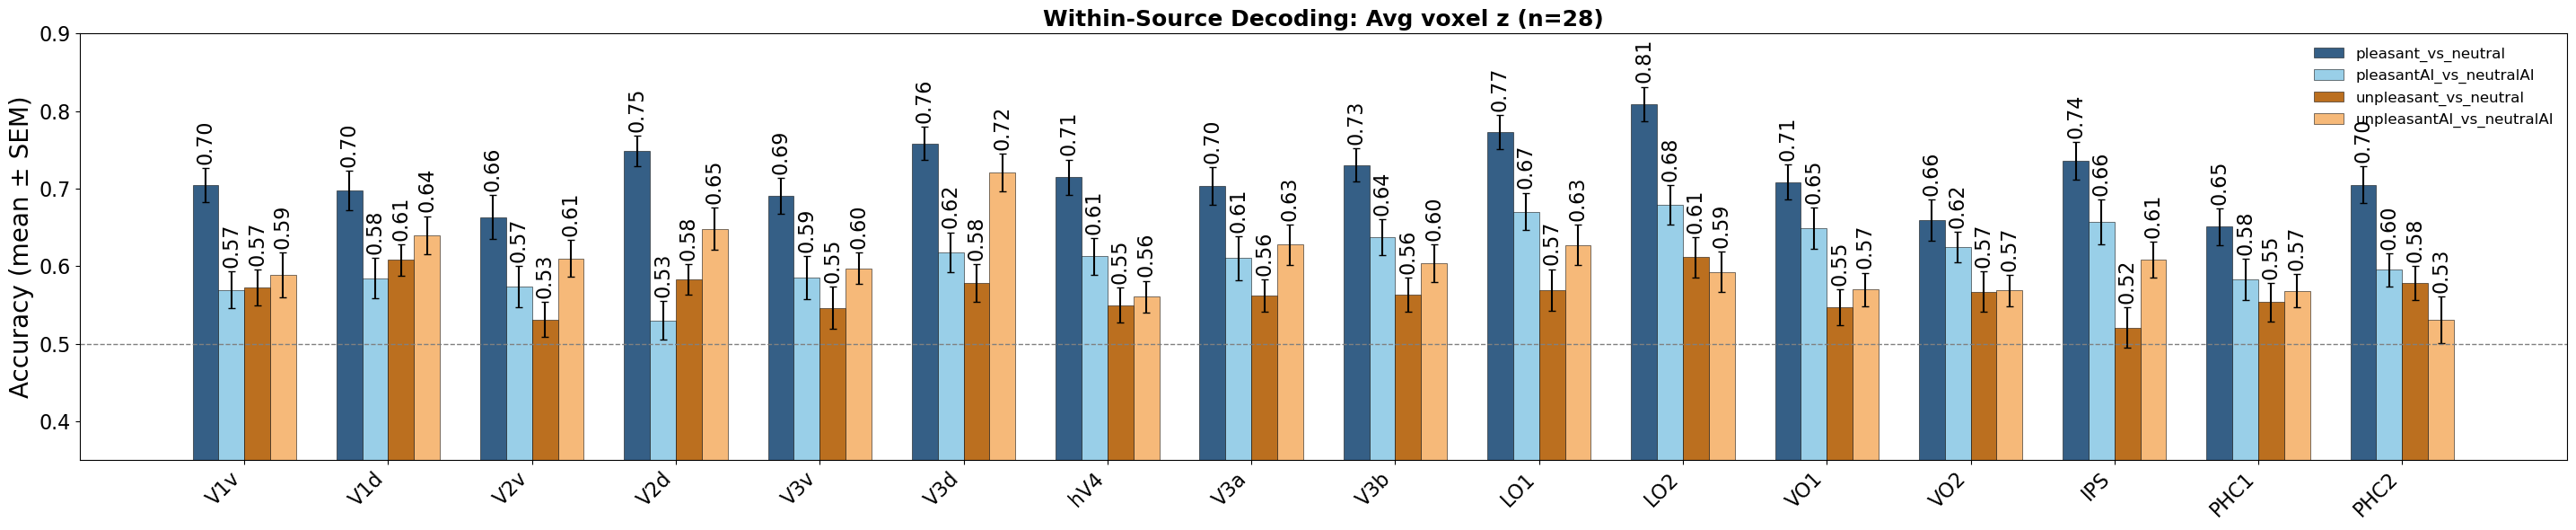

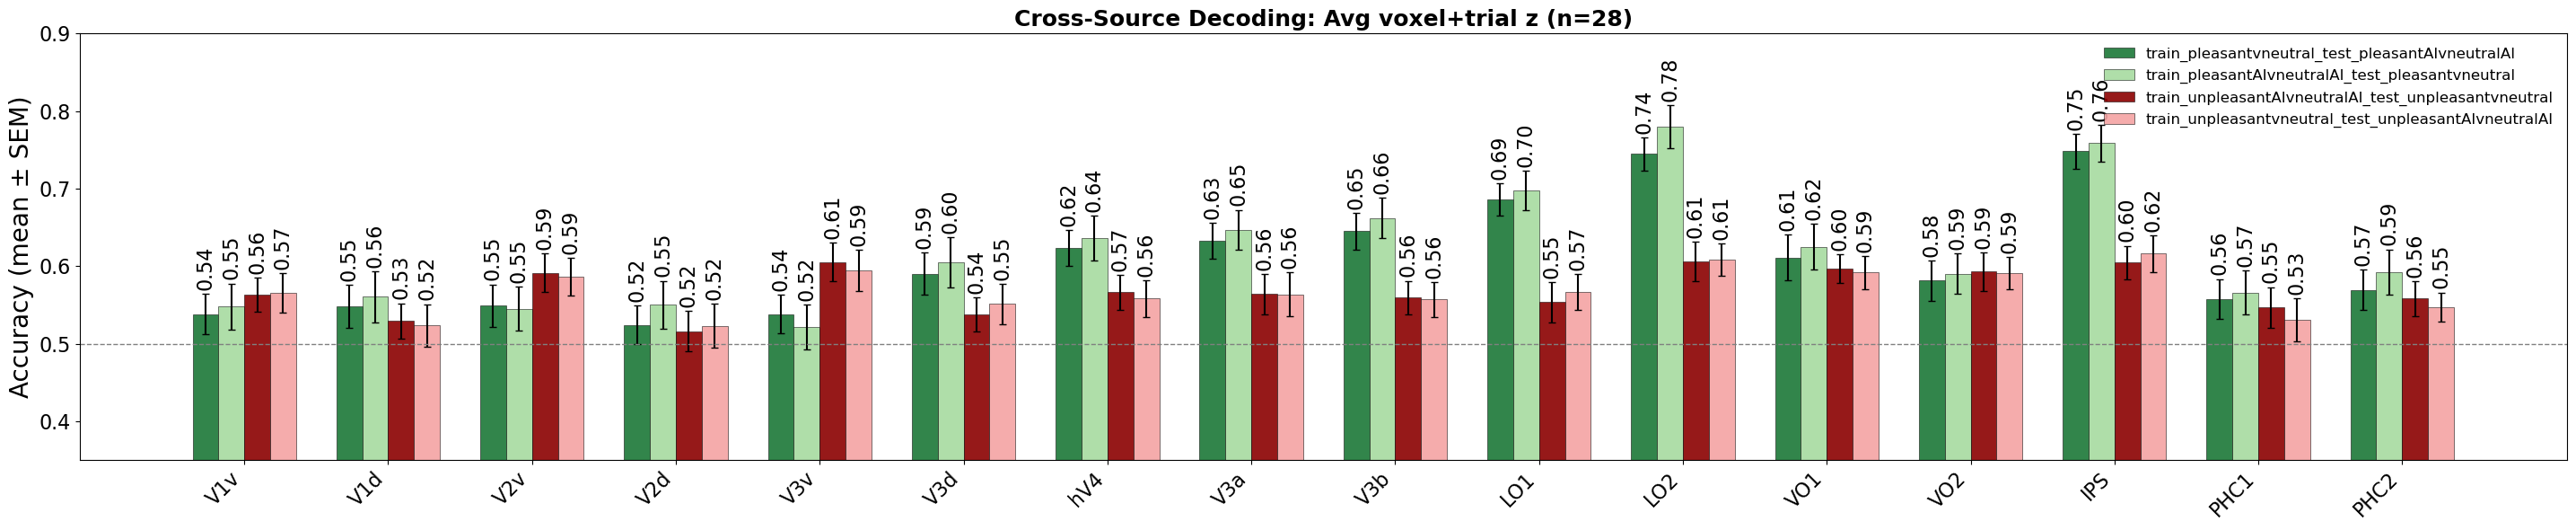

In [15]:
# ============================
# Subjects: remove Sub3, Sub8
# ============================
subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]
roi_names = list(roi_masks.keys())

within_colors = {
    'pleasant_vs_neutral': '#1f4e79',
    'pleasantAI_vs_neutralAI': '#8ecae6',
    'unpleasant_vs_neutral': '#b45f06',
    'unpleasantAI_vs_neutralAI': '#f6b26b'
}

cross_colors = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI': '#1b7837',
    'train_pleasantAIvneutralAI_test_pleasantvneutral': '#a6dba0',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': '#8b0000',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': '#f4a3a3'
}


def collect_avg_variant_data(comp, result_avg, z_mode):
    """Collect a specific z-score variant: n_subs x n_rois."""
    return np.array([
        [result_avg[s][comp][z_mode].get(r, np.nan) for r in roi_names]
        for s in subs_plot
    ])


# ============================
# Within-Source: Avg voxel z
# ============================
within_plot_comps = [
    'pleasant_vs_neutral',
    'pleasantAI_vs_neutralAI',
    'unpleasant_vs_neutral',
    'unpleasantAI_vs_neutralAI'
]

fig, ax = plt.subplots(1, 1, figsize=(max(18, len(roi_names) * 1.8), 6))
x = np.arange(len(roi_names))
width = 0.18
n_c = len(within_plot_comps)

for ci, comp in enumerate(within_plot_comps):
    md = collect_avg_variant_data(comp, results_within_avg, 'voxel_zscore')
    means = np.nanmean(md, axis=0)
    sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))
    offset = (ci - (n_c - 1) / 2) * width

    bars = ax.bar(
        x + offset, means, width, yerr=sems,
        color=within_colors[comp], label=comp,
        capsize=3, alpha=0.9, edgecolor='black', linewidth=0.4
    )
    ax.bar_label(bars, fmt='%.2f', fontsize=16, rotation=90, padding=3)

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Accuracy (mean ± SEM)', fontsize=20)
ax.set_title(f'Within-Source Decoding: Avg voxel z (n={len(subs_plot)})',
             fontsize=18, fontweight='bold')
ax.tick_params(axis='y', labelsize=16)
ax.set_xticks(x)
ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=16)
ax.set_ylim([0.35, 0.9])
ax.legend(fontsize=12, frameon=False, loc='upper right')
plt.tight_layout()
plt.show()


# ============================
# Cross-Source: Avg voxel+trial z
# ============================
cross_plot_comps = [
    'train_pleasantvneutral_test_pleasantAIvneutralAI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI'
]

fig, ax = plt.subplots(1, 1, figsize=(max(18, len(roi_names) * 1.8), 6))
x = np.arange(len(roi_names))
width = 0.18
n_c = len(cross_plot_comps)

for ci, comp in enumerate(cross_plot_comps):
    md = collect_avg_variant_data(comp, results_cross_avg, 'voxel_trial_zscore')
    means = np.nanmean(md, axis=0)
    sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))
    offset = (ci - (n_c - 1) / 2) * width

    bars = ax.bar(
        x + offset, means, width, yerr=sems,
        color=cross_colors[comp], label=comp,
        capsize=3, alpha=0.9, edgecolor='black', linewidth=0.4
    )
    ax.bar_label(bars, fmt='%.2f', fontsize=16, rotation=90, padding=3)

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Accuracy (mean ± SEM)', fontsize=20)
ax.set_title(f'Cross-Source Decoding: Avg voxel+trial z (n={len(subs_plot)})',
             fontsize=18, fontweight='bold')
ax.tick_params(axis='y', labelsize=16)
ax.set_xticks(x)
ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=16)
ax.set_ylim([0.35, 0.9])
ax.legend(fontsize=12, frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

In [21]:
# %% [markdown]
# ## Permutation Test (Label Shuffling)
# Avg voxel+trial+source z mode only for both within and cross source decoding.
# Randomly permute condition labels to establish a null distribution (~50% chance).

# %% [code]
N_PERMS = 100


def decode_within_avg_new_permuted(d1, d2, z_mode_inside_fold, n_repeats=20, n_folds=4, n_avg_groups=3, rng_seed=0):
    """Same as decode_within_avg_new but with shuffled condition assignment."""
    all_data = np.vstack([d1, d2])
    rng = np.random.RandomState(rng_seed)
    perm_idx = rng.permutation(len(all_data))
    d1_perm = all_data[perm_idx[:len(d1)]]
    d2_perm = all_data[perm_idx[len(d1):]]
    return decode_within_avg_new(d1_perm, d2_perm, z_mode_inside_fold=z_mode_inside_fold,
                                 n_repeats=n_repeats, n_folds=n_folds, n_avg_groups=n_avg_groups)


def decode_cross_avg_new_permuted(train_d1, train_d2, test_d1, test_d2, z_mode_inside_fold, n_repeats=20, n_folds=4, rng_seed=0):
    """Same as decode_cross_avg_new but with shuffled condition assignment."""
    rng = np.random.RandomState(rng_seed)
    train_all = np.vstack([train_d1, train_d2])
    perm_tr = rng.permutation(len(train_all))
    tr1_perm = train_all[perm_tr[:len(train_d1)]]
    tr2_perm = train_all[perm_tr[len(train_d1):]]
    test_all = np.vstack([test_d1, test_d2])
    perm_te = rng.permutation(len(test_all))
    te1_perm = test_all[perm_te[:len(test_d1)]]
    te2_perm = test_all[perm_te[len(test_d1):]]
    return decode_cross_avg_new(tr1_perm, tr2_perm, te1_perm, te2_perm,
                                z_mode_inside_fold=z_mode_inside_fold,
                                n_repeats=n_repeats, n_folds=n_folds)


PERM_MODE = 'voxel_trial_source_zscore'


def process_one_subject_permutation(sub):
    """Run permutation decoding for one subject, voxel_trial_source_zscore only."""

    perm_wa = {f"{c1}_vs_{c2}": {PERM_MODE: {}} for c1, c2 in within_comparisons}
    perm_ca = {f"train_{c1}v{c2}_test_{c3}v{c4}": {PERM_MODE: {}}
               for c1, c2, c3, c4 in cross_comparisons}

    # --- Load onsets ---
    sub_onset_dir = os.path.join(onset_base_dir, sub, 'LogFiles')
    stim_names = []
    for run_name in runs:
        fpath = os.path.join(sub_onset_dir, f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(sub_onset_dir, f'{alt_name}.mat')
        mat = scipy.io.loadmat(fpath, squeeze_me=False)
        raw = mat['dataLog']
        for row in range(1, raw.shape[0]):
            c = raw[row, 1]
            if c.size == 0:
                continue
            if str(c.flat[0]).strip() == 'Stim on':
                stim_names.append(str(raw[row, 2].flat[0]).strip())

    categories = [stim_to_category[s] for s in stim_names]
    bl = pd.DataFrame({'beta_file': beta_file_list, 'category': categories, 'stimulus': stim_names})

    # --- Load betas ---
    sub_dir = os.path.join(beta_dir, sub)
    first_img = nib.load(os.path.join(sub_dir, bl['beta_file'].iloc[0]))
    ref_img_global = first_img
    n_vox = int(np.prod(first_img.shape))
    data = np.zeros((600, n_vox), dtype=np.float32)
    for idx in range(600):
        data[idx] = nib.load(os.path.join(sub_dir, bl.iloc[idx]['beta_file'])).get_fdata().flatten().astype(np.float32)

    # --- Process each ROI ---
    for roi_name, roi_mask in roi_masks.items():
        voxel_idx = get_roi_voxels(roi_mask, ref_img_global)

        cond_data = {}
        for cond in all_categories:
            idx_arr = bl[bl['category'] == cond].index.values
            cond_data[cond] = data[idx_arr][:, voxel_idx]

        valid = np.ones(len(voxel_idx), dtype=bool)
        for cond in all_categories:
            valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
        if np.sum(valid) < 10:
            continue
        for cond in all_categories:
            cond_data[cond] = cond_data[cond][:, valid]

        voxel_source_z = compute_voxel_source_zscore(cond_data)

        # --- Within-source permutations ---
        for cond1, cond2 in within_comparisons:
            comp = f"{cond1}_vs_{cond2}"
            perm_wa[comp][PERM_MODE][roi_name] = [
                decode_within_avg_new_permuted(
                    voxel_source_z[cond1], voxel_source_z[cond2],
                    z_mode_inside_fold='voxel_trial_zscore_only', rng_seed=p
                ) for p in range(N_PERMS)
            ]

        # --- Cross-source permutations ---
        for train_c1, train_c2, test_c1, test_c2 in cross_comparisons:
            comp = f"train_{train_c1}v{train_c2}_test_{test_c1}v{test_c2}"
            perm_ca[comp][PERM_MODE][roi_name] = [
                decode_cross_avg_new_permuted(
                    voxel_source_z[train_c1], voxel_source_z[train_c2],
                    voxel_source_z[test_c1], voxel_source_z[test_c2],
                    z_mode_inside_fold='voxel_trial_zscore_only', rng_seed=p
                ) for p in range(N_PERMS)
            ]

    return {'sub': sub, 'perm_within_avg': perm_wa, 'perm_cross_avg': perm_ca}


# --- Run permutation in parallel ---
print(f"Running permutation test ({N_PERMS} perms, {PERM_MODE}) for {len(subs)} subjects...")
perm_results_list = Parallel(n_jobs=N_JOBS, prefer='threads', verbose=10)(
    delayed(process_one_subject_permutation)(sub) for sub in subs
)

# --- Merge permutation results ---
results_perm_within_avg = {}
results_perm_cross_avg = {}

for r in perm_results_list:
    sub = r['sub']
    results_perm_within_avg[sub] = r['perm_within_avg']
    results_perm_cross_avg[sub] = r['perm_cross_avg']

print(f"Permutation test complete.")


# --- Print permutation summary ---
roi_names = list(roi_masks.keys())

def print_perm_summary(perm_dict, real_dict, title):
    print(f"\n{'='*90}")
    print(f"  {title}  (n={len(subs)} subjects, {N_PERMS} perms each)")
    print(f"{'='*90}")
    for comp in perm_dict[subs[0]].keys():
        print(f"\n  {comp}  [{PERM_MODE}]:")
        print(f"    {'ROI':<12}  {'real':>8}  {'perm mean':>10}  {'perm std':>10}")
        print(f"    {'-'*44}")
        for roi in roi_names:
            sub_perm_means = [np.mean(perm_dict[s][comp][PERM_MODE].get(roi, [np.nan])) for s in subs]
            sub_real = [real_dict[s][comp][PERM_MODE].get(roi, np.nan) for s in subs]
            print(f"    {roi:<12}  {np.mean(sub_real):>8.3f}  {np.mean(sub_perm_means):>10.3f}  {np.std(sub_perm_means):>10.3f}")

print_perm_summary(results_perm_within_avg, results_within_avg,
                   "Permutation Null — Within-source Avg(random)")
print_perm_summary(results_perm_cross_avg, results_cross_avg,
                   "Permutation Null — Cross-source Avg(random)")

Running permutation test (100 perms, voxel_trial_source_zscore) for 30 subjects...


[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 355.8min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 361.1min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 771.3min
[Parallel(n_jobs=6)]: Done  23 out of  30 | elapsed: 1197.7min remaining: 364.5min
[Parallel(n_jobs=6)]: Done  27 out of  30 | elapsed: 1368.7min remaining: 152.1min


Permutation test complete.

  Permutation Null — Within-source Avg(random)  (n=30 subjects, 100 perms each)

  pleasantAI_vs_neutralAI  [voxel_trial_source_zscore]:
    ROI               real   perm mean    perm std
    --------------------------------------------
    V1v              0.576       0.506       0.014
    V1d              0.597       0.508       0.013
    V2v              0.571       0.502       0.013
    V2d              0.512       0.508       0.013
    V3v                nan         nan         nan
    V3d              0.601       0.505       0.014
    hV4                nan         nan         nan
    V3a              0.625       0.509       0.016
    V3b              0.634       0.502       0.016
    LO1                nan         nan         nan
    LO2                nan         nan         nan
    VO1                nan         nan         nan
    VO2              0.608       0.510       0.012
    IPS              0.668       0.511       0.012
    PHC1             

[Parallel(n_jobs=6)]: Done  30 out of  30 | elapsed: 1372.3min finished


## Permutation

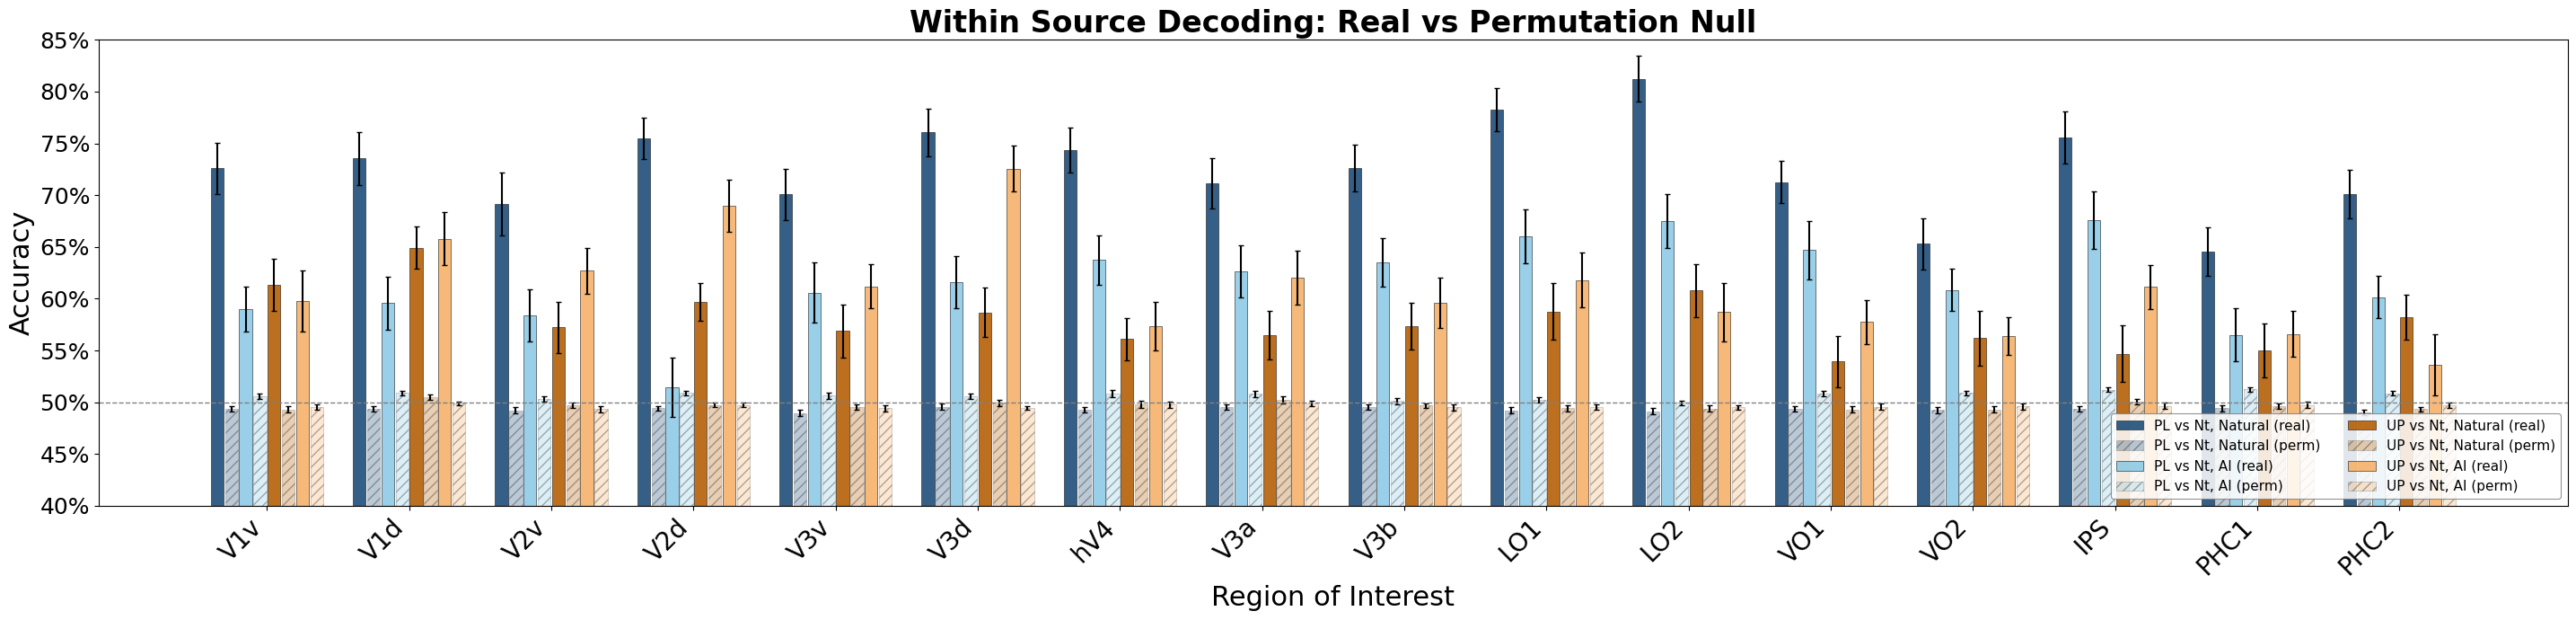

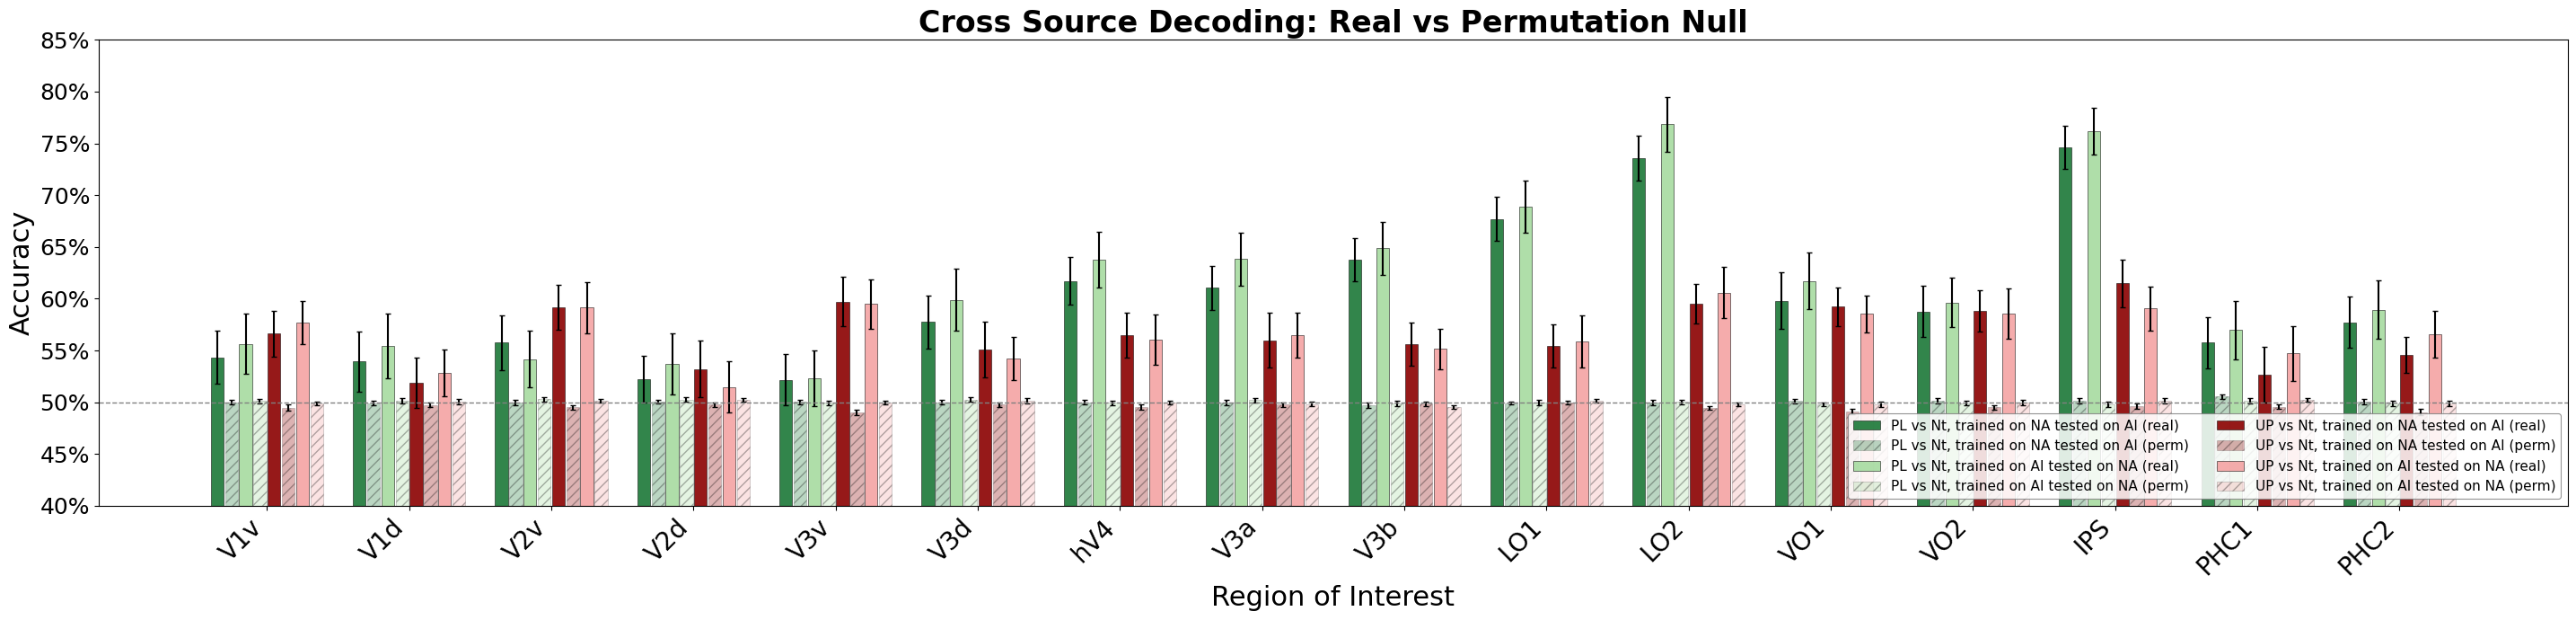

In [22]:
# ============================
# Permutation Test Results: Real vs Null
# voxel_trial_source_zscore only
# ============================
import matplotlib.ticker as mticker

subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]
roi_names = list(roi_masks.keys())
PERM_MODE = 'voxel_trial_source_zscore'

within_order = ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI',
                'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']

cross_order = ['train_pleasantvneutral_test_pleasantAIvneutralAI',
               'train_pleasantAIvneutralAI_test_pleasantvneutral',
               'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
               'train_unpleasantAIvneutralAI_test_unpleasantvneutral']

within_labels = {
    'pleasant_vs_neutral':       'PL vs Nt, Natural',
    'pleasantAI_vs_neutralAI':   'PL vs Nt, AI',
    'unpleasant_vs_neutral':     'UP vs Nt, Natural',
    'unpleasantAI_vs_neutralAI': 'UP vs Nt, AI',
}

cross_labels = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI':     'PL vs Nt, trained on NA tested on AI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral':     'PL vs Nt, trained on AI tested on NA',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': 'UP vs Nt, trained on NA tested on AI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': 'UP vs Nt, trained on AI tested on NA',
}

# Real colors (solid)
within_colors_real = {
    'pleasant_vs_neutral': '#1f4e79',
    'pleasantAI_vs_neutralAI': '#8ecae6',
    'unpleasant_vs_neutral': '#b45f06',
    'unpleasantAI_vs_neutralAI': '#f6b26b'
}

cross_colors_real = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI': '#1b7837',
    'train_pleasantAIvneutralAI_test_pleasantvneutral': '#a6dba0',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': '#8b0000',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': '#f4a3a3'
}


def get_real_data(result_dict, comp, z_mode, roi_names, subs_plot):
    return np.array([
        [result_dict[s][comp][z_mode].get(r, np.nan) for r in roi_names]
        for s in subs_plot
    ])


def get_perm_data(perm_dict, comp, z_mode, roi_names, subs_plot):
    """Get mean of permutation distribution per subject per ROI."""
    return np.array([
        [np.mean(perm_dict[s][comp][z_mode].get(r, [np.nan])) for r in roi_names]
        for s in subs_plot
    ])


def plot_real_vs_perm(real_dict, perm_dict, comp_order, color_dict, label_dict, title):
    n_comps = len(comp_order)
    n_rois = len(roi_names)

    fig, ax = plt.subplots(1, 1, figsize=(max(18, n_rois * 1.8), 7))
    x = np.arange(n_rois)
    # Each comparison gets 2 bars: real + perm
    pair_width = 0.09
    group_width = 2 * pair_width + 0.02  # real + perm + small gap
    total_width = n_comps * group_width

    for ci, comp in enumerate(comp_order):
        real = get_real_data(real_dict, comp, PERM_MODE, roi_names, subs_plot)
        perm = get_perm_data(perm_dict, comp, PERM_MODE, roi_names, subs_plot)

        real_means = np.nanmean(real, axis=0)
        real_sems = np.nanstd(real, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(real), axis=0))
        perm_means = np.nanmean(perm, axis=0)
        perm_sems = np.nanstd(perm, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(perm), axis=0))

        base_offset = (ci - (n_comps - 1) / 2) * group_width

        # Real bar
        ax.bar(x + base_offset - pair_width/2 - 0.005, real_means, pair_width,
               yerr=real_sems, color=color_dict[comp], label=label_dict[comp] + ' (real)',
               capsize=2, alpha=0.9, edgecolor='black', linewidth=0.4)

        # Perm bar (hatched, same color but lighter)
        ax.bar(x + base_offset + pair_width/2 + 0.005, perm_means, pair_width,
               yerr=perm_sems, color=color_dict[comp], label=label_dict[comp] + ' (perm)',
               capsize=2, alpha=0.3, edgecolor='black', linewidth=0.4, hatch='///')

    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Accuracy', fontsize=22)
    ax.set_xlabel('Region of Interest', fontsize=22)
    ax.set_title(title, fontsize=24, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=20)
    ax.set_ylim([0.40, 0.85])
    legend = ax.legend(fontsize=11, loc='lower right', frameon=True, ncol=2,
                       facecolor='white', framealpha=0.85, edgecolor='gray')
    legend.get_frame().set_linewidth(0.8)
    plt.tight_layout()
    plt.show()


# ============================
# Within-Source: Real vs Perm
# ============================
plot_real_vs_perm(
    results_within_avg, results_perm_within_avg,
    within_order, within_colors_real, within_labels,
    'Within Source Decoding: Real vs Permutation Null'
)

# ============================
# Cross-Source: Real vs Perm
# ============================
plot_real_vs_perm(
    results_cross_avg, results_perm_cross_avg,
    cross_order, cross_colors_real, cross_labels,
    'Cross Source Decoding: Real vs Permutation Null'
)

In [23]:
output_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
os.makedirs(output_dir, exist_ok=True)

all_results = {
    'within_single': results_within_single,
    'within_avg': results_within_avg,
    'within_erp': results_within_erp,
    'cross_single': results_cross_single,
    'cross_avg': results_cross_avg,
    'cross_erp': results_cross_erp,
    'perm_within_avg': results_perm_within_avg,
    'perm_cross_avg': results_perm_cross_avg,
    'subs': subs,
    'roi_names': roi_names,
    'within_comparisons': within_comparisons,
    'cross_comparisons': cross_comparisons,
    'single_z_modes': SINGLE_Z_MODES,
    'avg_z_modes': AVG_Z_MODES,
    'perm_z_mode': PERM_MODE,
    'n_perms': N_PERMS,
    'notes': {
        'avg_random_update': 'Avg(random) z-score variants normalize single trials before random grouping/averaging.',
        'avg_variants': {
            'no_zscore': 'raw trials -> random average -> SVM',
            'voxel_zscore': 'pattern norm across voxels within each single trial before averaging',
            'trial_zscore': 'voxel-wise standardization across single trials before averaging',
            'voxel_trial_zscore': 'pattern norm first, then voxel-wise standardization before averaging',
            'source_zscore': 'source-level normalized trials before averaging',
            'voxel_source_zscore': 'pattern norm across voxels first, then source-level normalization before averaging',
            'trial_voxel_zscore': 'trial z then pattern norm (inside CV)',
            'trial_source_zscore': 'source z (before CV) then trial z (inside CV)',
            'trial_voxel_source_zscore': 'source z (before CV) then trial z then pattern norm (inside CV)',
            'voxel_trial_source_zscore': 'source z (before CV) then pattern norm then trial z (inside CV)',
        },
        'permutation_test': f'{N_PERMS} permutations, voxel_trial_source_zscore mode only, label shuffling null distribution',
    }
}

save_path = os.path.join(output_dir, 'decoding_multisub_avg_zscore_variants.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(all_results, f)
print(f"Results saved to: {save_path}")
print(f"Keys: {list(all_results.keys())}")

Results saved to: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_zscore_variants.pkl
Keys: ['within_single', 'within_avg', 'within_erp', 'cross_single', 'cross_avg', 'cross_erp', 'perm_within_avg', 'perm_cross_avg', 'subs', 'roi_names', 'within_comparisons', 'cross_comparisons', 'single_z_modes', 'avg_z_modes', 'perm_z_mode', 'n_perms', 'notes']


In [ ]:
# %% [markdown]
# ## Permutation Test (Label Shuffling)
# Avg voxel+trial+source z mode only for both within and cross source decoding.
# Randomly permute condition labels to establish a null distribution (~50% chance).

# %% [code]
N_PERMS = 10000


def decode_within_avg_new_permuted(d1, d2, z_mode_inside_fold, n_repeats=20, n_folds=4, n_avg_groups=3, rng_seed=0):
    """Same as decode_within_avg_new but with shuffled condition assignment."""
    all_data = np.vstack([d1, d2])
    rng = np.random.RandomState(rng_seed)
    perm_idx = rng.permutation(len(all_data))
    d1_perm = all_data[perm_idx[:len(d1)]]
    d2_perm = all_data[perm_idx[len(d1):]]
    return decode_within_avg_new(d1_perm, d2_perm, z_mode_inside_fold=z_mode_inside_fold,
                                 n_repeats=n_repeats, n_folds=n_folds, n_avg_groups=n_avg_groups)


def decode_cross_avg_new_permuted(train_d1, train_d2, test_d1, test_d2, z_mode_inside_fold, n_repeats=20, n_folds=4, rng_seed=0):
    """Same as decode_cross_avg_new but with shuffled condition assignment."""
    rng = np.random.RandomState(rng_seed)
    train_all = np.vstack([train_d1, train_d2])
    perm_tr = rng.permutation(len(train_all))
    tr1_perm = train_all[perm_tr[:len(train_d1)]]
    tr2_perm = train_all[perm_tr[len(train_d1):]]
    test_all = np.vstack([test_d1, test_d2])
    perm_te = rng.permutation(len(test_all))
    te1_perm = test_all[perm_te[:len(test_d1)]]
    te2_perm = test_all[perm_te[len(test_d1):]]
    return decode_cross_avg_new(tr1_perm, tr2_perm, te1_perm, te2_perm,
                                z_mode_inside_fold=z_mode_inside_fold,
                                n_repeats=n_repeats, n_folds=n_folds)


PERM_MODE = 'voxel_trial_source_zscore'


def process_one_subject_permutation(sub):
    """Run permutation decoding for one subject, voxel_trial_source_zscore only."""

    perm_wa = {f"{c1}_vs_{c2}": {PERM_MODE: {}} for c1, c2 in within_comparisons}
    perm_ca = {f"train_{c1}v{c2}_test_{c3}v{c4}": {PERM_MODE: {}}
               for c1, c2, c3, c4 in cross_comparisons}

    # --- Load onsets ---
    sub_onset_dir = os.path.join(onset_base_dir, sub, 'LogFiles')
    stim_names = []
    for run_name in runs:
        fpath = os.path.join(sub_onset_dir, f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(sub_onset_dir, f'{alt_name}.mat')
        mat = scipy.io.loadmat(fpath, squeeze_me=False)
        raw = mat['dataLog']
        for row in range(1, raw.shape[0]):
            c = raw[row, 1]
            if c.size == 0:
                continue
            if str(c.flat[0]).strip() == 'Stim on':
                stim_names.append(str(raw[row, 2].flat[0]).strip())

    categories = [stim_to_category[s] for s in stim_names]
    bl = pd.DataFrame({'beta_file': beta_file_list, 'category': categories, 'stimulus': stim_names})

    # --- Load betas ---
    sub_dir = os.path.join(beta_dir, sub)
    first_img = nib.load(os.path.join(sub_dir, bl['beta_file'].iloc[0]))
    ref_img_global = first_img
    n_vox = int(np.prod(first_img.shape))
    data = np.zeros((600, n_vox), dtype=np.float32)
    for idx in range(600):
        data[idx] = nib.load(os.path.join(sub_dir, bl.iloc[idx]['beta_file'])).get_fdata().flatten().astype(np.float32)

    # --- Process each ROI ---
    for roi_name, roi_mask in roi_masks.items():
        voxel_idx = get_roi_voxels(roi_mask, ref_img_global)

        cond_data = {}
        for cond in all_categories:
            idx_arr = bl[bl['category'] == cond].index.values
            cond_data[cond] = data[idx_arr][:, voxel_idx]

        valid = np.ones(len(voxel_idx), dtype=bool)
        for cond in all_categories:
            valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
        if np.sum(valid) < 10:
            continue
        for cond in all_categories:
            cond_data[cond] = cond_data[cond][:, valid]

        voxel_source_z = compute_voxel_source_zscore(cond_data)

        # --- Within-source permutations ---
        for cond1, cond2 in within_comparisons:
            comp = f"{cond1}_vs_{cond2}"
            perm_wa[comp][PERM_MODE][roi_name] = [
                decode_within_avg_new_permuted(
                    voxel_source_z[cond1], voxel_source_z[cond2],
                    z_mode_inside_fold='voxel_trial_zscore_only', rng_seed=p
                ) for p in range(N_PERMS)
            ]

        # --- Cross-source permutations ---
        for train_c1, train_c2, test_c1, test_c2 in cross_comparisons:
            comp = f"train_{train_c1}v{train_c2}_test_{test_c1}v{test_c2}"
            perm_ca[comp][PERM_MODE][roi_name] = [
                decode_cross_avg_new_permuted(
                    voxel_source_z[train_c1], voxel_source_z[train_c2],
                    voxel_source_z[test_c1], voxel_source_z[test_c2],
                    z_mode_inside_fold='voxel_trial_zscore_only', rng_seed=p
                ) for p in range(N_PERMS)
            ]

    return {'sub': sub, 'perm_within_avg': perm_wa, 'perm_cross_avg': perm_ca}


# --- Run permutation in parallel ---
print(f"Running permutation test ({N_PERMS} perms, {PERM_MODE}) for {len(subs)} subjects...")
perm_results_list = Parallel(n_jobs=N_JOBS, prefer='threads', verbose=10)(
    delayed(process_one_subject_permutation)(sub) for sub in subs
)

# --- Merge permutation results ---
results_perm_within_avg = {}
results_perm_cross_avg = {}

for r in perm_results_list:
    sub = r['sub']
    results_perm_within_avg[sub] = r['perm_within_avg']
    results_perm_cross_avg[sub] = r['perm_cross_avg']

print(f"Permutation test complete.")


# --- Print permutation summary ---
roi_names = list(roi_masks.keys())

def print_perm_summary(perm_dict, real_dict, title):
    print(f"\n{'='*90}")
    print(f"  {title}  (n={len(subs)} subjects, {N_PERMS} perms each)")
    print(f"{'='*90}")
    for comp in perm_dict[subs[0]].keys():
        print(f"\n  {comp}  [{PERM_MODE}]:")
        print(f"    {'ROI':<12}  {'real':>8}  {'perm mean':>10}  {'perm std':>10}")
        print(f"    {'-'*44}")
        for roi in roi_names:
            sub_perm_means = [np.mean(perm_dict[s][comp][PERM_MODE].get(roi, [np.nan])) for s in subs]
            sub_real = [real_dict[s][comp][PERM_MODE].get(roi, np.nan) for s in subs]
            print(f"    {roi:<12}  {np.mean(sub_real):>8.3f}  {np.mean(sub_perm_means):>10.3f}  {np.std(sub_perm_means):>10.3f}")

print_perm_summary(results_perm_within_avg, results_within_avg,
                   "Permutation Null — Within-source Avg(random)")
print_perm_summary(results_perm_cross_avg, results_cross_avg,
                   "Permutation Null — Cross-source Avg(random)")

Running permutation test (10000 perms, voxel_trial_source_zscore) for 30 subjects...


[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 19783.1min


## Save Results

In [10]:
output_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
os.makedirs(output_dir, exist_ok=True)

all_results = {
    'within_single': results_within_single,
    'within_avg': results_within_avg,
    'within_erp': results_within_erp,
    'cross_single': results_cross_single,
    'cross_avg': results_cross_avg,
    'cross_erp': results_cross_erp,
    'subs': subs,
    'roi_names': roi_names,
    'within_comparisons': within_comparisons,
    'cross_comparisons': cross_comparisons,
    'single_z_modes': SINGLE_Z_MODES,
    'avg_z_modes': AVG_Z_MODES,
    'notes': {
        'avg_random_update': 'Avg(random) z-score variants normalize single trials before random grouping/averaging.',
        'avg_variants': {
            'no_zscore': 'raw trials -> random average -> SVM',
            'voxel_zscore': 'pattern norm across voxels within each single trial before averaging',
            'trial_zscore': 'voxel-wise standardization across single trials before averaging',
            'voxel_trial_zscore': 'pattern norm first, then voxel-wise standardization before averaging',
            'source_zscore': 'source-level normalized trials before averaging',
            'voxel_source_zscore': 'pattern norm across voxels first, then source-level normalization before averaging',
        }
    }
}

save_path = os.path.join(output_dir, 'decoding_multisub_avg_zscore_variants.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(all_results, f)
print(f"Results saved to: {save_path}")


Results saved to: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_zscore_variants.pkl
